# Tissue A STABL multi-omics pipeline

This notebook runs the tissue-specific Protein/RNA STABL workflow for crop classification.

**Run order:**
1. Load the tissue-specific 2020 training and 2021 validation files.
2. Split features into Protein and RNA blocks.
3. Run STABL feature selection and save selected panels.
4. Train/evaluate Random Forest models and fusion models.
5. Save paper-style ROC, performance, confusion-matrix, and SHAP figures.

All original input/output paths are preserved.

In [1]:
# !pip -q uninstall -y stabl knockpy scikit-learn scipy numpy pandas

# # Hard remove leftover sklearn folders (to prevent 1.8.0 coming back)
# !rm -rf /usr/local/lib/python3.12/dist-packages/sklearn \
#         /usr/local/lib/python3.12/dist-packages/scikit_learn* \
#         /usr/local/lib/python3.12/dist-packages/scikit_learn-*.dist-info \
#         /usr/local/lib/python3.12/dist-packages/scikit_learn.libs || true

# # Pin to Colab-friendly versions + STABL-compatible sklearn
# !pip -q install --no-cache-dir --force-reinstall --only-binary=:all: \
#   "numpy==2.1.3" "pandas==2.2.2" "scipy==1.14.1" "scikit-learn==1.5.2"

# # Install knockpy (required by STABL import)
# !pip -q install --no-cache-dir "knockpy"

# # Install STABL without changing dependencies
# !pip -q install --no-deps --force-reinstall "git+https://github.com/gregbellan/Stabl.git@v1.0.1-lw"


## Setup and imports

In [2]:
# Core imports
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

from stabl.stabl import Stabl

/usr/local/lib/python3.12/dist-packages/stabl/stabl.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Joblib temporary directory

In [4]:
os.environ["JOBLIB_TEMP_FOLDER"] = "/content/joblib_tmp"
os.makedirs("/content/joblib_tmp", exist_ok=True)

## Environment check

In [5]:
import sys, sklearn
print(sys.executable)
print(sklearn.__version__)

/usr/bin/python3
1.5.2


## Load tissue A data and encode crop labels

In [6]:
# ============================================================
# Cell 1) Load data (X/y) + build 4-class crop labels (tissue=A)
# ============================================================

import random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
FIG_DIR = Path("/content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A")
FIG_DIR.mkdir(parents=True, exist_ok=True)
# -----------------------------
# 0) Choose data directory automatically
#    Priority: Google Drive (Colab) -> Uploaded files (/mnt/data)
# -----------------------------
drive_dir  = Path("/content/drive/MyDrive/Bee/stabl_RNA_Protein/data")
upload_dir = Path("/mnt/data")

if drive_dir.exists():
    DATA_DIR = drive_dir
elif upload_dir.exists():
    DATA_DIR = upload_dir
else:
    raise FileNotFoundError(
        "Cannot find DATA_DIR. Expected either /content/drive/MyDrive/crop_tissue/data or /mnt/data."
    )

# -----------------------------
# 0.5) Tissue-specific file names (A)
# NOTE: These are the filenames created after splitting the dataset by tissue.
# -----------------------------
paths = {
    "X_train": DATA_DIR /  "multiomics_X_2020_A.csv",
    "y_train": DATA_DIR / "multiomics_y_2020_A.csv",
    "X_val":   DATA_DIR /"multiomics_X_val_2021_A.csv",
    "y_val":   DATA_DIR /"multiomics_y_val_2021_A.csv",
}
missing = [f"{k} -> {p}" for k, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing file(s):\n" + "\n".join(missing))

print("[INFO] Using DATA_DIR:", DATA_DIR)

# -----------------------------
# 1) Load X (features)
# -----------------------------
def read_X(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # If an index column sneaks in, drop it
    if df.columns[0].startswith("Unnamed") or df.columns[0].lower() in ("index",):
        df = df.drop(columns=[df.columns[0]])
    df.columns = df.columns.astype(str)

    # Safety: if metadata columns are present in X, remove them
    drop_cols = [c for c in ["join_key", "crops"] if c in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    return df

X_train = read_X(paths["X_train"])
X_val   = read_X(paths["X_val"])
print("[INFO] X_train:", X_train.shape, "X_val:", X_val.shape)

# -----------------------------
# 2) Load y and extract 4-class crop label
# - y file has columns: join_key, crops
# - crops looks like "HBB_H" (crop_tissue). We convert it to "HBB" (crop only).
# -----------------------------
def read_y_crop_only(path: Path) -> pd.Series:
    ydf = pd.read_csv(path)

    # Prefer explicit 'crops' column
    if "crops" in ydf.columns:
        crop_tissue = ydf["crops"].astype(str)
    else:
        # Fallback: parse the first column if needed
        y_raw = ydf.iloc[:, 0].astype(str)
        crop_tissue = y_raw.str.split("|", n=1).str[0]

    # Convert "HBB_H" -> "HBB" (4-class crop)
    crop_only = crop_tissue.str.split("_", n=1).str[0]
    return crop_only

y_train_cls = read_y_crop_only(paths["y_train"])
y_val_cls   = read_y_crop_only(paths["y_val"])

print("[INFO] train classes:", sorted(y_train_cls.unique().tolist()))
print("[INFO] val   classes:", sorted(y_val_cls.unique().tolist()))

unknown = set(y_val_cls.unique()) - set(y_train_cls.unique())
if unknown:
    raise ValueError(f"[ERROR] y_val has unseen classes not in y_train: {sorted(list(unknown))}")

# -----------------------------
# 3) Encode labels (multiclass -> 0..K-1) and define 'classes'
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_cls.to_numpy())
y_val_enc   = le.transform(y_val_cls.to_numpy())
classes = np.unique(y_train_enc)

print("[INFO] le.classes_:", list(le.classes_))
print("[INFO] encoded class ids:", classes)

if len(X_train) != len(y_train_enc):
    raise ValueError(f"[ERROR] X_train rows ({len(X_train)}) != y_train length ({len(y_train_enc)})")
if len(X_val) != len(y_val_enc):
    raise ValueError(f"[ERROR] X_val rows ({len(X_val)}) != y_val length ({len(y_val_enc)})")

print("[INFO] Sample counts match (X and y).")

[INFO] Using DATA_DIR: /content/drive/MyDrive/Bee/stabl_RNA_Protein/data
[INFO] X_train: (40, 17306) X_val: (40, 17306)
[INFO] train classes: ['CAC', 'CAS', 'CRA', 'HBB']
[INFO] val   classes: ['CAC', 'CAS', 'CRA', 'HBB']
[INFO] le.classes_: ['CAC', 'CAS', 'CRA', 'HBB']
[INFO] encoded class ids: [0 1 2 3]
[INFO] Sample counts match (X and y).


## Inspect loaded feature tables

In [7]:
# Inspect X_train
print("[X_train] shape:", X_train.shape)
print("[X_train] first 20 columns:", list(X_train.columns[:20]))
display(X_train.head())

# Inspect X_val
print("[X_val] shape:", X_val.shape)
print("[X_val] first 20 columns:", list(X_val.columns[:20]))
display(X_val.head())

[X_train] shape: (40, 17306)
[X_train] first 20 columns: ['prot__NP_001010975', 'prot__NP_001011563', 'prot__NP_001011564', 'prot__NP_001011570', 'prot__NP_001011572', 'prot__NP_001011573', 'prot__NP_001011574', 'prot__NP_001011578', 'prot__NP_001011579', 'prot__NP_001011580', 'prot__NP_001011583', 'prot__NP_001011584', 'prot__NP_001011586', 'prot__NP_001011589', 'prot__NP_001011592', 'prot__NP_001011594', 'prot__NP_001011597', 'prot__NP_001011598', 'prot__NP_001011599', 'prot__NP_001011600']


,prot__NP_001010975,prot__NP_001011563,prot__NP_001011564,prot__NP_001011570,prot__NP_001011572,prot__NP_001011573,prot__NP_001011574,prot__NP_001011578,prot__NP_001011579,prot__NP_001011580,...,rna__Vamp7,rna__vas,rna__Vg,rna__Vha16,rna__Vhdl,rna__Wat,rna__Y-e3,rna__Y-f,rna__Y-h,rna__Y-y
0,18.537055,18.345994,12.027201,13.233660,18.495500,1.714521,15.375192,20.457667,17.706017,17.491008,...,10.411996,9.432215,20.523786,13.138308,15.242591,12.629251,10.261299,9.600514,6.784221,9.692809
1,18.296491,18.208992,12.559927,13.099231,18.612940,1.963888,15.839307,20.931533,17.616807,17.784763,...,10.462295,9.276285,19.952271,13.353862,14.521792,12.175555,10.245591,9.763598,7.207735,10.735066
2,18.771941,18.131988,11.827073,13.387937,18.580741,1.713562,16.211335,20.641389,18.585241,18.274683,...,10.399910,9.180938,20.276099,13.195428,15.216708,12.118925,9.861797,9.433297,6.876340,10.341738
3,18.883974,18.179846,11.207289,13.169828,18.543583,1.904225,16.609524,20.832870,18.376952,18.046730,...,10.482255,9.424025,20.673570,13.309107,15.312161,12.207085,10.183649,9.462514,7.143486,9.886203
4,18.758366,17.896155,12.217579,13.410995,18.350369,1.750537,17.138022,20.529019,19.083534,19.028664,...,10.513075,9.534055,19.972988,13.109930,14.368949,12.332787,10.623666,9.383158,6.738995,8.646124


[X_val] shape: (40, 17306)
[X_val] first 20 columns: ['prot__NP_001010975', 'prot__NP_001011563', 'prot__NP_001011564', 'prot__NP_001011570', 'prot__NP_001011572', 'prot__NP_001011573', 'prot__NP_001011574', 'prot__NP_001011578', 'prot__NP_001011579', 'prot__NP_001011580', 'prot__NP_001011583', 'prot__NP_001011584', 'prot__NP_001011586', 'prot__NP_001011589', 'prot__NP_001011592', 'prot__NP_001011594', 'prot__NP_001011597', 'prot__NP_001011598', 'prot__NP_001011599', 'prot__NP_001011600']


,prot__NP_001010975,prot__NP_001011563,prot__NP_001011564,prot__NP_001011570,prot__NP_001011572,prot__NP_001011573,prot__NP_001011574,prot__NP_001011578,prot__NP_001011579,prot__NP_001011580,...,rna__Vamp7,rna__vas,rna__Vg,rna__Vha16,rna__Vhdl,rna__Wat,rna__Y-e3,rna__Y-f,rna__Y-h,rna__Y-y
0,18.109780,18.251598,11.533412,13.611290,17.164475,1.820183,16.621251,18.326996,18.246523,17.433479,...,10.491283,9.189257,18.619999,13.329563,13.344565,12.033210,11.582789,10.095772,7.246851,6.871078
1,17.928501,18.632580,11.940736,13.802314,17.432330,1.810622,16.538792,18.886042,18.375400,17.589827,...,10.377099,9.100577,19.768637,13.278986,14.206464,12.042665,10.902126,9.588347,7.105816,8.461762
2,18.381289,19.104914,12.007938,13.316041,18.038271,2.194972,17.395543,19.442565,19.322153,18.538674,...,10.377220,9.463431,21.103360,13.549605,15.353663,12.130292,10.151474,9.713094,6.799007,8.669171
3,18.230185,18.857128,12.285041,13.501713,17.645862,2.037622,16.307133,19.065847,17.901150,17.157061,...,10.432075,9.144190,20.497215,13.629214,15.254831,12.019103,11.557294,9.545008,6.741265,6.695693
4,17.844724,18.595232,11.676473,14.191800,18.117892,2.033399,16.566207,19.221552,18.705109,17.879888,...,10.268951,9.231419,19.445232,13.454870,14.138386,11.960141,10.836167,9.549427,7.166782,8.244098


## Define STABL helper functions and temporal wrapper

In [8]:
# ============================================================
# MULTI-OMICS STABL (Temporal Train/Val) — library-style wrapper
# This version supports key_col=None, so the pipeline can run without a join_key column.
# ============================================================

# -----------------------------
# Helpers
# -----------------------------
def split_multiomics_by_prefix(X_df, key_col=None, prefixes=("prot__", "rna__")):
    """
    Split a wide table into {omic: df} using column prefixes.

    OPTION 1 behavior:
      - If key_col=None, keep the existing index unchanged; no join_key column is required.
      - If key_col is provided and exists in the table, use that column as the index.
    """
    X = X_df.copy()

    if key_col is not None and key_col in X.columns:
        X = X.set_index(key_col)

    out = {}
    for pref in prefixes:
        omic = pref.replace("__", "").replace("_", "")  # prot__/rna__ -> prot/rna
        cols = [c for c in X.columns if c.startswith(pref)]
        if cols:
            out[omic] = X[cols]

    if not out:
        raise ValueError("No omics detected. Check prefixes like ('prot__','rna__').")
    return out


def get_selected_feature_mask(model, columns):
    """Defensive selected-mask getter across STABL versions."""
    if hasattr(model, "get_support"):
        return np.asarray(model.get_support(), dtype=bool)
    if hasattr(model, "support_"):
        return np.asarray(model.support_, dtype=bool)
    if hasattr(model, "selected_features_"):
        sf = model.selected_features_
        if isinstance(sf, (list, np.ndarray)) and len(sf) and isinstance(sf[0], str):
            sset = set(sf)
            return np.array([c in sset for c in columns], dtype=bool)
        return np.array(sf, dtype=bool)
    raise RuntimeError("Cannot find selected-features attribute in fitted STABL object.")


def get_stabl_feature_scores(model, columns):
    """Try to fetch stability scores; if 2D reduce by max."""
    cand = [
        "stabl_scores_",
        "stability_scores_",
        "selection_frequencies_",
        "selection_frequency_",
        "scores_",
        "feature_scores_",
    ]
    for a in cand:
        if hasattr(model, a):
            s = np.asarray(getattr(model, a))
            if s.ndim == 1 and s.shape[0] == len(columns):
                return s
            if s.ndim == 2:
                if s.shape[1] == len(columns):
                    return np.max(s, axis=0)
                if s.shape[0] == len(columns):
                    return np.max(s, axis=1)
    return None


def fit_coef_importance_on_selected(X_train_s, y_bin, selected_features, random_state):
    """Fit L2 logit on selected features for stable coef ranking."""
    if len(selected_features) == 0:
        return pd.DataFrame(columns=["feature", "coef", "coef_abs"])

    clf = LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=200000,
        random_state=random_state,
    )
    clf.fit(X_train_s[selected_features], y_bin)
    coef = clf.coef_.ravel()
    return pd.DataFrame({"feature": selected_features, "coef": coef, "coef_abs": np.abs(coef)})


def build_preprocessing_pipeline(var_thresh=0.01):
    """VarianceThreshold -> Imputer(median) -> StandardScaler"""
    return Pipeline(
        steps=[
            ("variance", VarianceThreshold(var_thresh)),
            ("impute", SimpleImputer(strategy="median")),
            ("std", StandardScaler()),
        ]
    )


def pipeline_fit_transform_df(pipe, X_df):
    """
    Fit pipeline and return standardized DataFrame.
    Robust feature name handling across sklearn versions.
    """
    Xt = pipe.fit_transform(X_df)
    if hasattr(pipe, "get_feature_names_out"):
        cols = pipe.get_feature_names_out()
    else:
        cols = np.array(X_df.columns[: Xt.shape[1]])
    return pd.DataFrame(Xt, index=X_df.index, columns=cols)


def pipeline_transform_df(pipe, X_df):
    Xt = pipe.transform(X_df)
    if hasattr(pipe, "get_feature_names_out"):
        cols = pipe.get_feature_names_out()
    else:
        cols = np.array(X_df.columns[: Xt.shape[1]])
    return pd.DataFrame(Xt, index=X_df.index, columns=cols)


def _safe_class_name(x):
    return str(x).replace("/", "_")


def late_fusion_stack_train_valid(train_prob_dict, y_train_enc, valid_prob_dict, random_state):
    """
    Simple sklearn stacking:
      - multiclass: multinomial LR on concatenated per-omic probs
      - binary: LR on concatenated per-omic probs
    """
    omics = list(train_prob_dict.keys())
    Xtr = np.concatenate([train_prob_dict[o].to_numpy() for o in omics], axis=1)
    Xva = np.concatenate([valid_prob_dict[o].to_numpy() for o in omics], axis=1)

    K = len(np.unique(y_train_enc))
    if K > 2:
        stacker = LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            class_weight="balanced",
            max_iter=200000,
            random_state=random_state,
        )
        stacker.fit(Xtr, y_train_enc)
        Pva = stacker.predict_proba(Xva)
        return pd.DataFrame(
            Pva,
            index=valid_prob_dict[omics[0]].index,
            columns=[f"class_{k}" for k in range(K)]
        )
    else:
        stacker = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            class_weight="balanced",
            max_iter=200000,
            random_state=random_state,
        )
        stacker.fit(Xtr, y_train_enc)
        pva = stacker.predict_proba(Xva)[:, 1]
        return pd.Series(pva, index=valid_prob_dict[omics[0]].index, name="late_fusion_prob")


# -----------------------------
# Main: multi_omic_stabl_temporal
# -----------------------------
def multi_omic_stabl_temporal(
    data_dict_train,
    y_train_enc,
    data_dict_valid=None,
    y_valid_enc=None,
    classes=None,
    le=None,
    stabl_template=None,
    save_path=str(DATA_DIR / "results_stabl_multiomics_A"),
    preprocessing=None,
    resume=True,
    early_fusion=True,
    late_fusion=True,
    final_model_max_iter=200000,
    random_state=42,
):
    """
    Temporal (train/val) runner:
      1) Fit one-vs-rest STABL separately for each omic and save/resume checkpoints.
      2) Rebuild the per-omic union feature panel from saved CSV files.
      3) fused panel = concat(per-omic union-selected)
      4) Optionally train per-omic prediction models and late-fusion stacking.
      5) Optionally train an early-fusion prediction model.

    OPTION 1 compatible:
      - data_dict_train and data_dict_valid can be created without a join_key column.
        (created with split_multiomics_by_prefix(..., key_col=None)).
    """
    save_path = Path(save_path)
    tv_path = save_path / "Training-Validation"
    summary_path = save_path / "Summary"
    tv_path.mkdir(parents=True, exist_ok=True)
    summary_path.mkdir(parents=True, exist_ok=True)

    if preprocessing is None:
        preprocessing = build_preprocessing_pipeline(var_thresh=0.01)

    if classes is None:
        classes = sorted(np.unique(y_train_enc).tolist())

    if le is None:
        class_names = [str(c) for c in classes]
    else:
        class_names = [le.classes_[c] for c in classes]

    if stabl_template is None:
        raise ValueError("stabl_template must be provided (configured STABL instance).")

    # =========================================================
    # 1) OvR STABL per omic (resume-friendly)
    # =========================================================
    for omic, X_train_omic in data_dict_train.items():
        existing = set()
        if resume:
            for p in tv_path.glob(f"stabl_rank_selected_only_{omic}_*.csv"):
                safe = p.stem.replace(f"stabl_rank_selected_only_{omic}_", "")
                existing.add(safe)

        if existing:
            print(f"[INFO] ({omic}) Found {len(existing)} completed checkpoints. Will skip them.")
        else:
            print(f"[INFO] ({omic}) No checkpoints found (or resume=False).")

        for c, cname in zip(classes, class_names):
            safe_name = _safe_class_name(cname)
            if resume and safe_name in existing:
                print(f"[SKIP] ({omic}) class='{cname}' already done")
                continue

            print(f"\n[OvR] ({omic}) STABL for class '{cname}' vs rest...")

            # Preprocess (fit on train only)
            pipe = clone(preprocessing)
            Xtr_std = pipeline_fit_transform_df(pipe, X_train_omic)

            y_bin = (np.asarray(y_train_enc) == c).astype(int)

            stabl_c = clone(stabl_template)
            stabl_c.fit(Xtr_std, y_bin)

            mask = get_selected_feature_mask(stabl_c, Xtr_std.columns)
            selected_feats = Xtr_std.columns[mask].tolist()
            stabl_scores = get_stabl_feature_scores(stabl_c, Xtr_std.columns)

            df_coef = fit_coef_importance_on_selected(
                X_train_s=Xtr_std,
                y_bin=y_bin,
                selected_features=selected_feats,
                random_state=random_state,
            )

            df_full = pd.DataFrame({"feature": Xtr_std.columns, "selected": mask.astype(int)})
            df_full["stabl_score"] = stabl_scores if stabl_scores is not None else np.nan
            df_full = df_full.merge(df_coef, on="feature", how="left")

            df_full = df_full.sort_values(
                by=["stabl_score", "selected", "coef_abs"],
                ascending=[False, False, False],
                na_position="last",
            ).reset_index(drop=True)
            df_full["rank"] = np.arange(1, len(df_full) + 1)

            df_sel = df_full[df_full["selected"] == 1].copy()

            df_full.to_csv(tv_path / f"stabl_rank_all_features_{omic}_{safe_name}.csv", index=False)
            df_sel.to_csv(tv_path / f"stabl_rank_selected_only_{omic}_{safe_name}.csv", index=False)

            print(f"[DONE] ({omic}) class='{cname}': selected {len(df_sel)}")
            print(f"[SAVE] stabl_rank_all_features_{omic}_{safe_name}.csv")
            print(f"[SAVE] stabl_rank_selected_only_{omic}_{safe_name}.csv")

    # =========================================================
    # 2) Per-omic union rebuild FROM DISK
    # =========================================================
    per_omic_selected_cols = {}
    per_omic_union_tables = {}

    for omic in data_dict_train.keys():
        all_full_csvs = sorted(tv_path.glob(f"stabl_rank_all_features_{omic}_*.csv"))
        if not all_full_csvs:
            raise RuntimeError(f"No per-class CSVs found for omic='{omic}' in {tv_path}")

        df0 = pd.read_csv(all_full_csvs[0])
        feats = df0["feature"].tolist()
        feat_set = set(feats)

        selected_union = np.zeros(len(feats), dtype=bool)
        stabl_acc = np.full(len(feats), -np.inf, dtype=float)
        coef_acc = np.full(len(feats), -np.inf, dtype=float)

        for csv_path in all_full_csvs:
            df = pd.read_csv(csv_path)
            df = df[df["feature"].isin(feat_set)].copy()
            idx = df.set_index("feature").reindex(feats)

            sel = idx["selected"].fillna(0).astype(int).to_numpy() > 0
            s = idx["stabl_score"].to_numpy() if "stabl_score" in idx.columns else np.full(len(feats), np.nan)
            ca = idx["coef_abs"].to_numpy() if "coef_abs" in idx.columns else np.full(len(feats), np.nan)

            selected_union |= sel
            stabl_acc = np.maximum(stabl_acc, np.where(np.isnan(s), -np.inf, s))
            coef_acc = np.maximum(coef_acc, np.where(np.isnan(ca), -np.inf, ca))

        df_union = pd.DataFrame({
            "feature": feats,
            "selected_in_union": selected_union.astype(int),
            "union_stabl_score_max": np.where(np.isfinite(stabl_acc), stabl_acc, np.nan),
            "union_coef_abs_max": np.where(np.isfinite(coef_acc), coef_acc, np.nan),
        }).sort_values(
            by=["union_stabl_score_max", "selected_in_union", "union_coef_abs_max"],
            ascending=[False, False, False],
            na_position="last",
        ).reset_index(drop=True)

        df_union["rank"] = np.arange(1, len(df_union) + 1)
        df_union_sel = df_union[df_union["selected_in_union"] == 1].copy()

        per_omic_union_tables[omic] = (df_union, df_union_sel)
        per_omic_selected_cols[omic] = df_union_sel["feature"].tolist()

        df_union.to_csv(tv_path / f"stabl_union_rank_all_features_{omic}.csv", index=False)
        df_union_sel.to_csv(tv_path / f"stabl_union_rank_selected_only_{omic}.csv", index=False)

        print(f"[SAVE] stabl_union_rank_all_features_{omic}.csv")
        print(f"[SAVE] stabl_union_rank_selected_only_{omic}.csv")
        print(f"[INFO] ({omic}) union selected: {len(per_omic_selected_cols[omic])}")

    # =========================================================
    # 3) Fused union feature list
    # =========================================================
    fused_selected_cols = []
    for omic in per_omic_selected_cols:
        fused_selected_cols.extend(per_omic_selected_cols[omic])

    pd.DataFrame({"feature": fused_selected_cols}).to_csv(
        tv_path / "stabl_fused_union_selected_features.csv",
        index=False
    )
    print(f"[SAVE] stabl_fused_union_selected_features.csv")
    print(f"[INFO] fused union selected: {len(fused_selected_cols)}")

    results = {
        "per_omic_selected_cols": per_omic_selected_cols,
        "fused_selected_cols": fused_selected_cols,
        "paths": {
            "save_path": str(save_path),
            "training_validation": str(tv_path),
            "summary": str(summary_path),
        },
    }

    # =========================================================
    # 4) Optional predictions on valid (early/late fusion)
    # =========================================================
    if data_dict_valid is None or y_valid_enc is None:
        return results

    # ---- per-omic predictions using union-selected features (in preprocessed space)
    train_prob_dict = {}
    valid_prob_dict = {}

    K = len(np.unique(y_train_enc))

    for omic in data_dict_train.keys():
        Xtr_raw = data_dict_train[omic]
        Xva_raw = data_dict_valid[omic]

        pipe = clone(preprocessing)
        Xtr_std = pipeline_fit_transform_df(pipe, Xtr_raw)
        Xva_std = pipeline_transform_df(pipe, Xva_raw)

        sel_feats = [f for f in per_omic_selected_cols[omic] if f in Xtr_std.columns]
        if len(sel_feats) == 0:
            sel_feats = list(Xtr_std.columns)

        if K > 2:
            clf = LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=final_model_max_iter,
                random_state=random_state,
            )
            clf.fit(Xtr_std[sel_feats], y_train_enc)
            Ptr = clf.predict_proba(Xtr_std[sel_feats])
            Pva = clf.predict_proba(Xva_std[sel_feats])

            train_prob_dict[omic] = pd.DataFrame(
                Ptr, index=Xtr_std.index, columns=[f"class_{k}" for k in range(K)]
            )
            valid_prob_dict[omic] = pd.DataFrame(
                Pva, index=Xva_std.index, columns=[f"class_{k}" for k in range(K)]
            )
        else:
            clf = LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=final_model_max_iter,
                random_state=random_state,
            )
            clf.fit(Xtr_std[sel_feats], y_train_enc)
            ptr = clf.predict_proba(Xtr_std[sel_feats])[:, 1]
            pva = clf.predict_proba(Xva_std[sel_feats])[:, 1]

            train_prob_dict[omic] = pd.DataFrame({"prob": ptr}, index=Xtr_std.index)
            valid_prob_dict[omic] = pd.DataFrame({"prob": pva}, index=Xva_std.index)

    results["per_omic_train_probs"] = train_prob_dict
    results["per_omic_valid_probs"] = valid_prob_dict

    # ---- late fusion stacking
    if late_fusion and len(train_prob_dict) >= 2:
        results["late_fusion_valid"] = late_fusion_stack_train_valid(
            train_prob_dict=train_prob_dict,
            y_train_enc=np.asarray(y_train_enc),
            valid_prob_dict=valid_prob_dict,
            random_state=random_state,
        )

    # ---- early fusion prediction (NOTE: uses all preprocessed features in fused space)
    if early_fusion:
        Xtr_tot = pd.concat(list(data_dict_train.values()), axis=1)
        Xva_tot = pd.concat(list(data_dict_valid.values()), axis=1)

        pipe = clone(preprocessing)
        Xtr_std = pipeline_fit_transform_df(pipe, Xtr_tot)
        Xva_std = pipeline_transform_df(pipe, Xva_tot)

        if K > 2:
            ef = LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=final_model_max_iter,
                random_state=random_state,
            )
            ef.fit(Xtr_std, y_train_enc)
            Pva = ef.predict_proba(Xva_std)
            results["early_fusion_valid_proba"] = pd.DataFrame(
                Pva, index=Xva_std.index, columns=[f"class_{k}" for k in range(K)]
            )
        else:
            ef = LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=final_model_max_iter,
                random_state=random_state,
            )
            ef.fit(Xtr_std, y_train_enc)
            pva = ef.predict_proba(Xva_std)[:, 1]
            results["early_fusion_valid_prob"] = pd.Series(pva, index=Xva_std.index, name="early_fusion_prob")

    return results


## Run STABL feature selection

In [9]:
# ============================================================
# Run the temporal STABL wrapper
#   - build data_dict_train/valid
#   - define stabl_template (if not defined yet)
#   - call multi_omic_stabl_temporal
# ============================================================

# 1) Build per-omic dicts (key_col=None: key_col=None)
data_dict_train = split_multiomics_by_prefix(X_train, key_col=None, prefixes=("prot__", "rna__"))
data_dict_valid = split_multiomics_by_prefix(X_val,   key_col=None, prefixes=("prot__", "rna__"))

print("[INFO] Omics detected:", list(data_dict_train.keys()))
for omic in data_dict_train:
    print(f"[INFO] {omic}: train={data_dict_train[omic].shape}, val={data_dict_valid[omic].shape}")

# 2) Define STABL template (ONLY if you haven't defined it already)
#    - key point: lambda_grid uses {"C": ...} when base_estimator is not a Pipeline
if "stabl_template" not in globals():
    base_bin = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=int(1e6),
        random_state=RANDOM_SEED,
    )

    stabl_template = Stabl(
        base_estimator=base_bin,
        n_bootstraps=500,
        artificial_type="knockoff",
        artificial_proportion=1.0,
        replace=False,
        fdr_threshold_range=np.arange(0.1, 1.0, 0.01),
        sample_fraction=0.5,
        random_state=RANDOM_SEED,
        lambda_grid={"C": np.linspace(0.01, 1.0, 10)},
        verbose=1,
    )

print("[INFO] stabl_template ready:", "stabl_template" in globals())

# 3) Run the temporal wrapper
results = multi_omic_stabl_temporal(
    data_dict_train=data_dict_train,
    y_train_enc=y_train_enc,
    data_dict_valid=data_dict_valid,
    y_valid_enc=y_val_enc,
    classes=classes,
    le=le,
    stabl_template=stabl_template,
    save_path=str(DATA_DIR / "results_stabl_multiomics_A"),  # change if you want
    resume=True,
    early_fusion=True,
    late_fusion=True,
    random_state=RANDOM_SEED,
)

# 4) Inspect outputs
print("\n[RESULT] per_omic_selected_cols sizes:")
for omic, feats in results["per_omic_selected_cols"].items():
    print(f"  - {omic}: {len(feats)}")

print("[RESULT] fused_selected_cols:", len(results["fused_selected_cols"]))
print("[RESULT] saved at:", results["paths"]["training_validation"])

# 5) If predictions exist, peek
if "late_fusion_valid" in results:
    print("\n[RESULT] late_fusion_valid head:")
    display(results["late_fusion_valid"])

if "early_fusion_valid_proba" in results:
    print("\n[RESULT] early_fusion_valid_proba head:")
    display(results["early_fusion_valid_proba"])

if "early_fusion_valid_prob" in results:
    print("\n[RESULT] early_fusion_valid_prob head:")
    display(results["early_fusion_valid_prob"])


[INFO] Omics detected: ['prot', 'rna']
[INFO] prot: train=(40, 5972), val=(40, 5972)
[INFO] rna: train=(40, 11334), val=(40, 11334)
[INFO] stabl_template ready: True
[INFO] (prot) Found 4 completed checkpoints. Will skip them.
[SKIP] (prot) class='CAC' already done
[SKIP] (prot) class='CAS' already done
[SKIP] (prot) class='CRA' already done
[SKIP] (prot) class='HBB' already done
[INFO] (rna) Found 4 completed checkpoints. Will skip them.
[SKIP] (rna) class='CAC' already done
[SKIP] (rna) class='CAS' already done
[SKIP] (rna) class='CRA' already done
[SKIP] (rna) class='HBB' already done
[SAVE] stabl_union_rank_all_features_prot.csv
[SAVE] stabl_union_rank_selected_only_prot.csv
[INFO] (prot) union selected: 31
[SAVE] stabl_union_rank_all_features_rna.csv
[SAVE] stabl_union_rank_selected_only_rna.csv
[INFO] (rna) union selected: 26
[SAVE] stabl_fused_union_selected_features.csv
[INFO] fused union selected: 57


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[RESULT] per_omic_selected_cols sizes:
  - prot: 31
  - rna: 26
[RESULT] fused_selected_cols: 57
[RESULT] saved at: /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation

[RESULT] late_fusion_valid head:


,class_0,class_1,class_2,class_3
0,0.131930,0.180235,0.092454,0.595381
1,0.138078,0.240529,0.095076,0.526317
2,0.102993,0.181177,0.087262,0.628567
3,0.077292,0.181814,0.079117,0.661778
4,0.146196,0.172682,0.093660,0.587462
5,0.110463,0.177448,0.086418,0.625671
6,0.297487,0.213653,0.111280,0.377580
7,0.102234,0.150406,0.078699,0.668661
8,0.124641,0.252792,0.095842,0.526725
9,0.072925,0.156803,0.073253,0.697018



[RESULT] early_fusion_valid_proba head:


,class_0,class_1,class_2,class_3
0,0.369743,0.135424,0.030311,0.464522
1,0.163041,0.292918,0.050046,0.493996
2,0.327677,0.097399,0.116030,0.458894
3,0.301759,0.308254,0.012826,0.377161
4,0.201609,0.147983,0.016349,0.634059
5,0.387564,0.107347,0.107654,0.397435
6,0.284415,0.134250,0.075429,0.505905
7,0.252257,0.123355,0.035350,0.589038
8,0.169695,0.336676,0.054312,0.439317
9,0.106658,0.129046,0.137091,0.627205


## Review selected features

In [10]:
# ============================================================
# Print selected feature sets for Protein and RNA
# ============================================================

print("\n================ SELECTED FEATURE SETS ================\n")

for omic in ["prot", "rna"]:
    feats = results["per_omic_selected_cols"].get(omic, [])
    print(f"[{omic.upper()}] n_selected = {len(feats)}")
    for i, f in enumerate(feats, 1):
        print(f"{i}. {f}")
    print("-" * 60)


================ SELECTED FEATURE SETS ================

[PROT] n_selected = 31
1. prot__XP_006567799
2. prot__XP_396012
3. prot__XP_001122470
4. prot__XP_006565473
5. prot__XP_026297057
6. prot__XP_396143
7. prot__XP_006561186
8. prot__XP_006572357
9. prot__XP_006561423
10. prot__XP_006558043
11. prot__XP_026296829
12. prot__XP_016772668
13. prot__XP_006562002
14. prot__XP_026298544
15. prot__XP_006569870
16. prot__XP_006563448
17. prot__NP_001128140
18. prot__XP_006570209
19. prot__XP_006570154
20. prot__XP_006566821
21. prot__NP_001014992
22. prot__XP_026298830
23. prot__XP_001120350
24. prot__XP_001121736
25. prot__XP_026301434
26. prot__XP_003251558
27. prot__XP_001120618
28. prot__XP_006564133
29. prot__XP_001122245
30. prot__XP_026297433
31. prot__XP_026297680
------------------------------------------------------------
[RNA] n_selected = 26
1. rna__LOC113218861
2. rna__LOC413101
3. rna__LOC100576679
4. rna__LOC725255
5. rna__Kakusei
6. rna__LOC102656039
7. rna__LOC552572
8. rn

## Save prediction outputs

In [11]:
# ============================================================
# Save fusion outputs and print feature counts
# ============================================================

from pathlib import Path

OUT_DIR = Path(results["paths"]["training_validation"])  # .../Training-Validation
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Print feature counts
# -----------------------------
# 1) Per-omic union-selected feature counts (from STABL union)
if "per_omic_selected_cols" in results:
    print("[INFO] per-omic union-selected feature counts:")
    for omic, feats in results["per_omic_selected_cols"].items():
        print(f"  - {omic}: {len(feats)}")

# 2) Fused union-selected feature count (prot union + rna union)
if "fused_selected_cols" in results:
    print(f"[INFO] fused union-selected features: {len(results['fused_selected_cols'])}")

# 3) Early-fusion model feature count used for prediction (after concat + preprocessing)
#    NOTE: In your wrapper, early fusion uses *all* preprocessed fused-space features, not the union-selected subset.
if "early_fusion_valid_proba" in results and results["early_fusion_valid_proba"] is not None:
    K = results["early_fusion_valid_proba"].shape[1]
    print(f"[INFO] early_fusion_valid_proba shape: n={results['early_fusion_valid_proba'].shape[0]}, K={K}")

# -----------------------------
# Save late fusion (multiclass proba)
# -----------------------------
if "late_fusion_valid" in results and results["late_fusion_valid"] is not None:
    lf_path = OUT_DIR / "pred_late_fusion_valid_proba.csv"
    results["late_fusion_valid"].to_csv(lf_path, index=True)
    print(f"[SAVE] late fusion -> {lf_path} (shape={results['late_fusion_valid'].shape})")
else:
    print("[INFO] late_fusion_valid not found (nothing saved).")

# -----------------------------
# Save early fusion (multiclass proba)
# -----------------------------
if "early_fusion_valid_proba" in results and results["early_fusion_valid_proba"] is not None:
    ef_path = OUT_DIR / "pred_early_fusion_valid_proba.csv"
    results["early_fusion_valid_proba"].to_csv(ef_path, index=True)
    print(f"[SAVE] early fusion -> {ef_path} (shape={results['early_fusion_valid_proba'].shape})")
else:
    print("[INFO] early_fusion_valid_proba not found (nothing saved).")


[INFO] per-omic union-selected feature counts:
  - prot: 31
  - rna: 26
[INFO] fused union-selected features: 57
[INFO] early_fusion_valid_proba shape: n=40, K=4
[SAVE] late fusion -> /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation/pred_late_fusion_valid_proba.csv (shape=(40, 4))
[SAVE] early fusion -> /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation/pred_early_fusion_valid_proba.csv (shape=(40, 4))


## Logistic-regression validation check

In [12]:
# ============================================================
# Load the selected panels from saved CSV files,
# tune logistic regression on 2020 only, and evaluate once on 2021
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.base import clone

preprocessing = Pipeline(
    steps=[
        ("variance", VarianceThreshold(0.01)),
        ("impute", SimpleImputer(strategy="median")),
        ("std", StandardScaler()),
    ]
)

print("[INFO] preprocessing ready:", preprocessing is not None)

# --- (A) Where results were saved ---
SAVE_DIR = Path(DATA_DIR) / "results_stabl_multiomics_A" / "Training-Validation"
if not SAVE_DIR.exists():
    raise FileNotFoundError(f"[ERROR] Cannot find SAVE_DIR: {SAVE_DIR}")

print("[INFO] SAVE_DIR:", SAVE_DIR)

# --- (B) Load selected_cols from CSV ---
def load_selected_cols_from_csv(save_dir: Path, mode="per_omic", omic=None):
    """
    mode:
      - "per_omic": load stabl_union_rank_selected_only_{omic}.csv
      - "fused":    load stabl_fused_union_selected_features.csv
    """
    if mode == "per_omic":
        if omic is None:
            raise ValueError("omic must be provided when mode='per_omic'")
        p = save_dir / f"stabl_union_rank_selected_only_{omic}.csv"
        if not p.exists():
            raise FileNotFoundError(f"[ERROR] Missing per-omic union file: {p}")
        df = pd.read_csv(p)
        if "feature" not in df.columns:
            raise ValueError(f"[ERROR] 'feature' column not found in {p.name}")
        return df["feature"].astype(str).tolist()

    elif mode == "fused":
        p = save_dir / "stabl_fused_union_selected_features.csv"
        if not p.exists():
            raise FileNotFoundError(f"[ERROR] Missing fused file: {p}")
        df = pd.read_csv(p)
        if "feature" not in df.columns:
            raise ValueError(f"[ERROR] 'feature' column not found in {p.name}")
        return df["feature"].astype(str).tolist()

    else:
        raise ValueError("mode must be 'per_omic' or 'fused'.")


# --- (C) Fit preprocessing on 2020 only, transform 2020/2021 (same as before) ---
def fit_preprocess_train_val(preprocessing, X_train_raw, X_val_raw):
    pipe = clone(preprocessing)
    Xtr_std = pipeline_fit_transform_df(pipe, X_train_raw)
    Xva_std = pipeline_transform_df(pipe, X_val_raw)
    Xva_std = Xva_std.reindex(columns=Xtr_std.columns)  # align
    return Xtr_std, Xva_std


def tune_and_eval_lr_temporal(Xtr_std, y_train_enc, Xva_std, y_val_enc, selected_cols, le=None, random_state=42):
    # selected_cols are expected to be in PREPROCESSED FEATURE NAME SPACE
    selected_cols = [c for c in selected_cols if c in Xtr_std.columns]
    if len(selected_cols) == 0:
        raise ValueError("[ERROR] selected_cols is empty after intersecting with preprocessed columns. Name-space mismatch.")

    Xtr = Xtr_std[selected_cols]
    Xva = Xva_std[selected_cols]

    clf = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=int(1e5),
        random_state=random_state,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    param_grid = {"C": np.logspace(-4, 4, 9)}

    grid = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        scoring="roc_auc_ovr",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    grid.fit(Xtr, y_train_enc)

    best = grid.best_estimator_
    proba = best.predict_proba(Xva)
    pred  = best.predict(Xva)

    micro_auc = roc_auc_score(y_val_enc, proba, average="micro", multi_class="ovr")
    macro_auc = roc_auc_score(y_val_enc, proba, average="macro", multi_class="ovr")

    report = None
    if le is not None:
        report = classification_report(y_val_enc, pred, target_names=le.classes_)

    return {
        "best_params": grid.best_params_,
        "best_cv_score_2020": grid.best_score_,
        "micro_auc_2021": micro_auc,
        "macro_auc_2021": macro_auc,
        "n_features_used": len(selected_cols),
        "report": report,
    }


# ============================================================
# (D) Run: per-omic (prot / rna)
# ============================================================
for omic in ["prot", "rna"]:
    print(f"\n================ {omic.upper()} ONLY ================")

    # 1) load panel from disk
    selected_cols = load_selected_cols_from_csv(SAVE_DIR, mode="per_omic", omic=omic)
    print("[INFO] loaded selected cols:", len(selected_cols))

    # 2) preprocess on 2020 only, transform 2021
    Xtr_std, Xva_std = fit_preprocess_train_val(preprocessing, data_dict_train[omic], data_dict_valid[omic])

    # 3) tune on 2020 only, eval once on 2021
    out = tune_and_eval_lr_temporal(Xtr_std, y_train_enc, Xva_std, y_val_enc, selected_cols, le=le, random_state=RANDOM_SEED)

    print("[TUNING] Best params:", out["best_params"])
    print("[TUNING] Best CV score (2020 only):", out["best_cv_score_2020"])
    print("[RESULT] 2021 Micro-AUC (OvR):", out["micro_auc_2021"])
    print("[RESULT] 2021 Macro-AUC (OvR):", out["macro_auc_2021"])
    print("[INFO]   #features used:", out["n_features_used"])
    if out["report"] is not None:
        print("\n[RESULT] Classification report (2021):")
        print(out["report"])


[INFO] preprocessing ready: True
[INFO] SAVE_DIR: /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation

================ PROT ONLY ================
[INFO] loaded selected cols: 31


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: 

[TUNING] Best params: {'C': np.float64(0.0001)}
[TUNING] Best CV score (2020 only): 1.0
[RESULT] 2021 Micro-AUC (OvR): 0.6483333333333333
[RESULT] 2021 Macro-AUC (OvR): 0.7275
[INFO]   #features used: 31

[RESULT] Classification report (2021):
              precision    recall  f1-score   support

         CAC       0.00      0.00      0.00        10
         CAS       0.07      0.10      0.08        10
         CRA       0.38      1.00      0.56        10
         HBB       0.00      0.00      0.00        10

    accuracy                           0.28        40
   macro avg       0.11      0.28      0.16        40
weighted avg       0.11      0.28      0.16        40


================ RNA ONLY ================
[INFO] loaded selected cols: 26
[TUNING] Best params: {'C': np.float64(0.0001)}
[TUNING] Best CV score (2020 only): 1.0
[RESULT] 2021 Micro-AUC (OvR): 0.4847916666666666
[RESULT] 2021 Macro-AUC (OvR): 0.48666666666666664
[INFO]   #features used: 26

[RESULT] Classification rep

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: 

## Random Forest tuning and ROC figures

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(



================ PROT RF ================
[INFO] loaded selected cols: 31
[INFO] Xtr_sub: (40, 31) Xva_sub: (40, 31)
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] best macro OvR AUC = 1.0000
[CV] best params = {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 517}
[AUC] temporal_valid_roc_micro_macro_RF_prot_2021 | micro: 0.687292 | macro: 0.716667
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_prot_2021.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_prot_2021.png


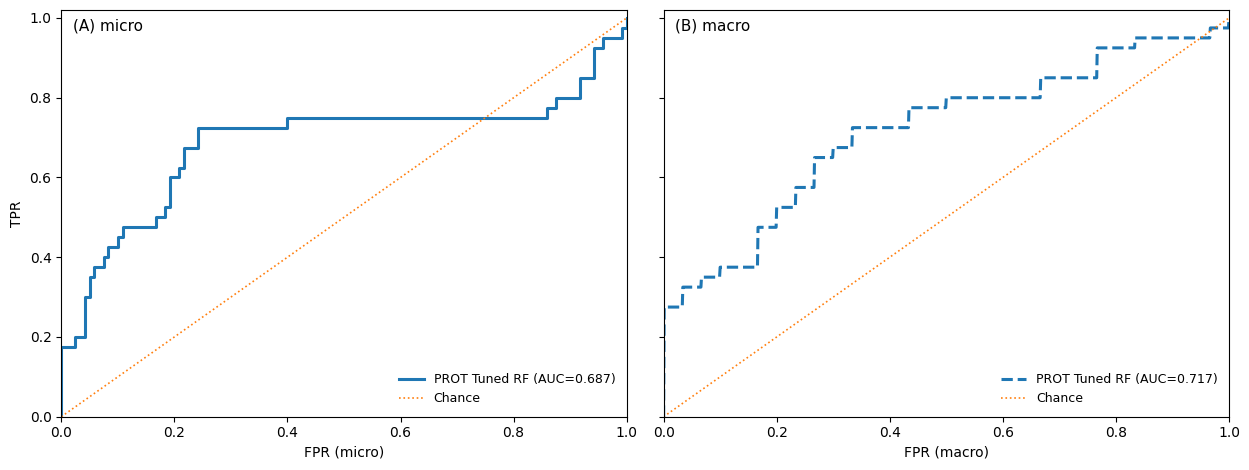

[AUC] train_roc_micro_macro_RF_prot_2020 | micro: 1.000000 | macro: 1.000000
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_prot_2020.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_prot_2020.png


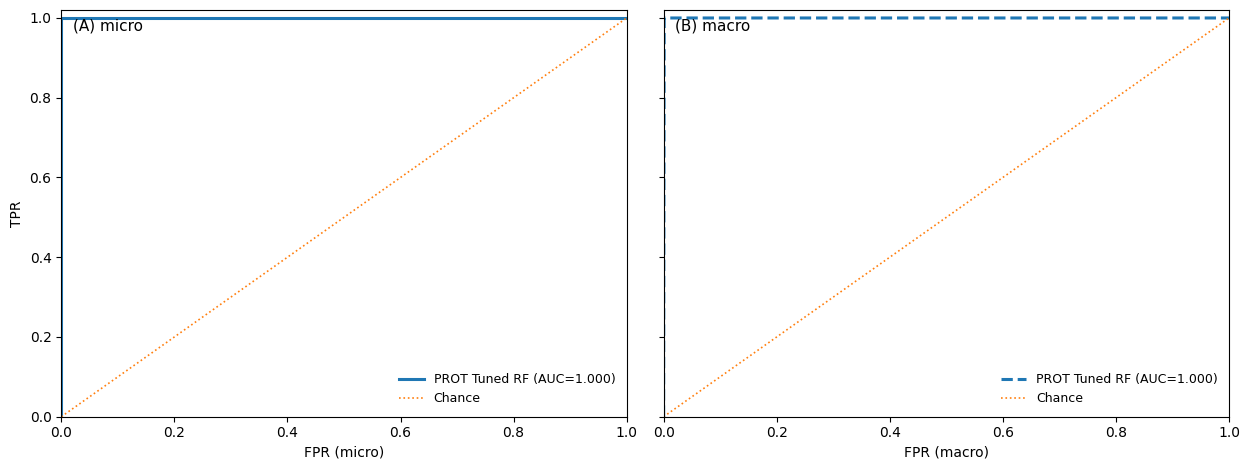


================ RNA RF ================
[INFO] loaded selected cols: 26
[INFO] Xtr_sub: (40, 26) Xva_sub: (40, 26)
Fitting 5 folds for each of 80 candidates, totalling 400 fits


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


[CV] best macro OvR AUC = 1.0000
[CV] best params = {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 517}
[AUC] temporal_valid_roc_micro_macro_RF_rna_2021 | micro: 0.446458 | macro: 0.428333
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_rna_2021.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_rna_2021.png


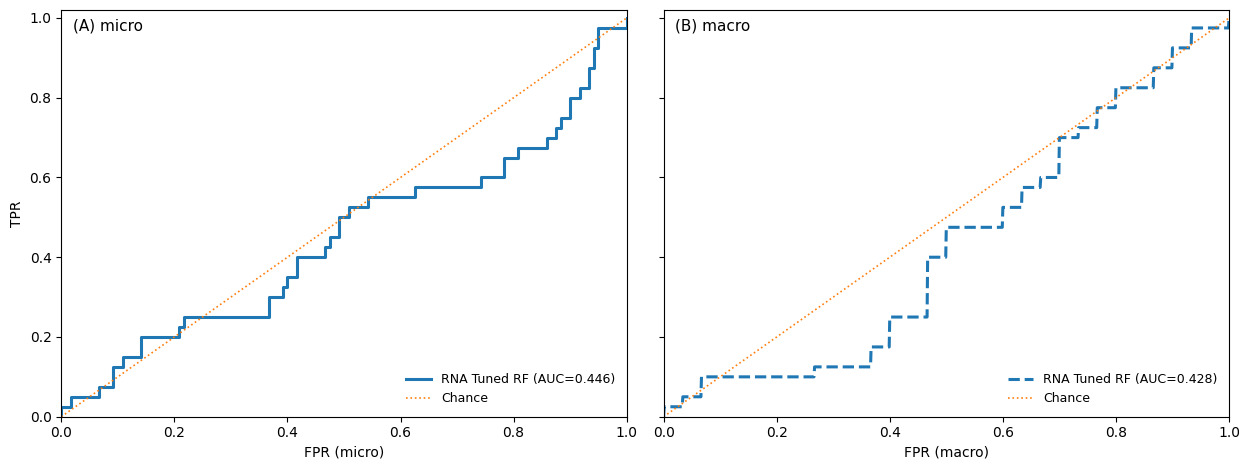

[AUC] train_roc_micro_macro_RF_rna_2020 | micro: 1.000000 | macro: 1.000000
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_rna_2020.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_rna_2020.png


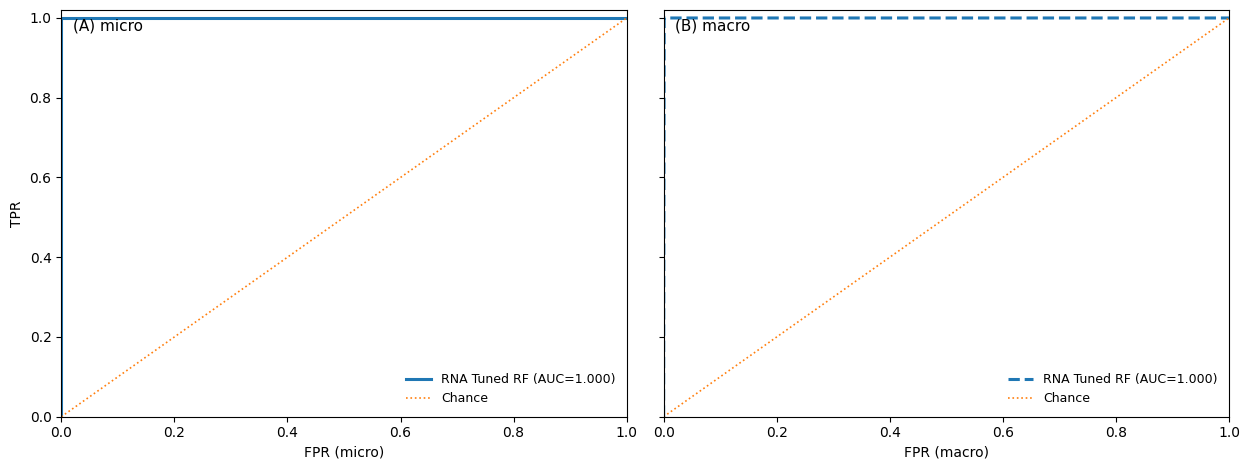


================ EARLY FUSION RF (AFTER SELECTION) ================
[INFO] loaded fused selected cols: 57
[INFO] Xtr_sub: (40, 57) Xva_sub: (40, 57)
Fitting 5 folds for each of 80 candidates, totalling 400 fits


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


[CV] best macro OvR AUC = 1.0000
[CV] best params = {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 517}
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation/pred_early_fusion_valid_proba.csv
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation/pred_early_fusion_train_proba.csv
[AUC] temporal_valid_roc_micro_macro_RF_earlyfusion_2021 | micro: 0.577708 | macro: 0.653333
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_earlyfusion_2021.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_earlyfusion_2021.png


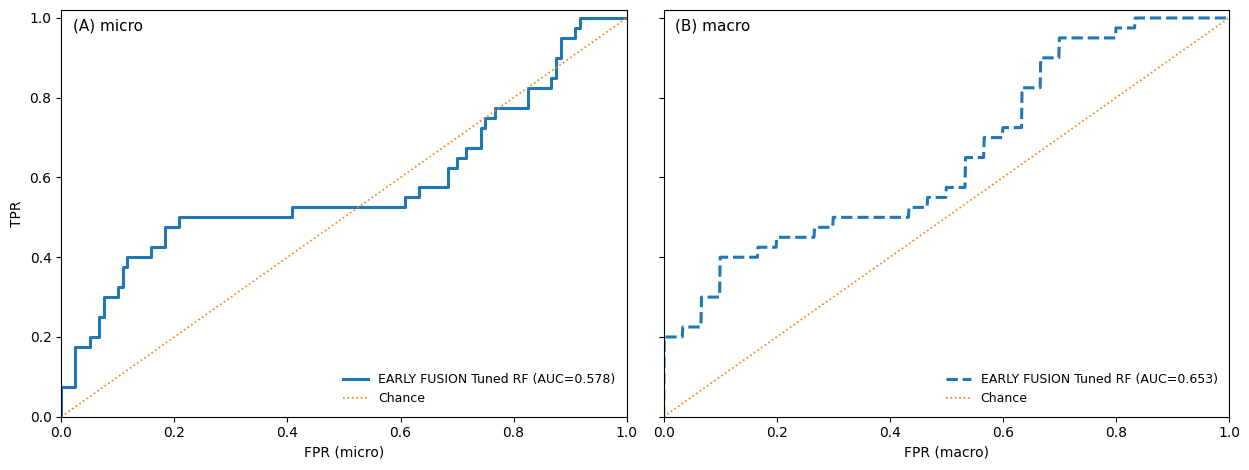

[AUC] train_roc_micro_macro_RF_earlyfusion_2020 | micro: 1.000000 | macro: 1.000000
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_earlyfusion_2020.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_earlyfusion_2020.png


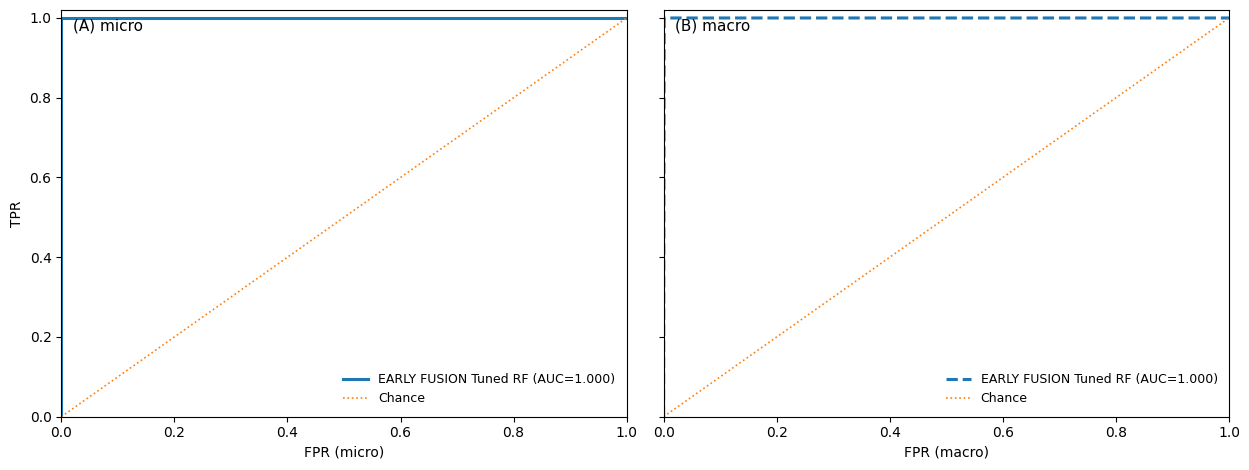


================ LATE FUSION RF ================
[INFO] late fusion built by averaging per-omic predicted probabilities
[INFO] validation proba shape: (40, 4)
[INFO] train proba shape: (40, 4)
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation/pred_late_fusion_valid_proba.csv
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/data/results_stabl_multiomics_A/Training-Validation/pred_late_fusion_train_proba.csv
[AUC] temporal_valid_roc_micro_macro_RF_latefusion_2021 | micro: 0.585417 | macro: 0.638333
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_latefusion_2021.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/temporal_valid_roc_micro_macro_RF_latefusion_2021.png


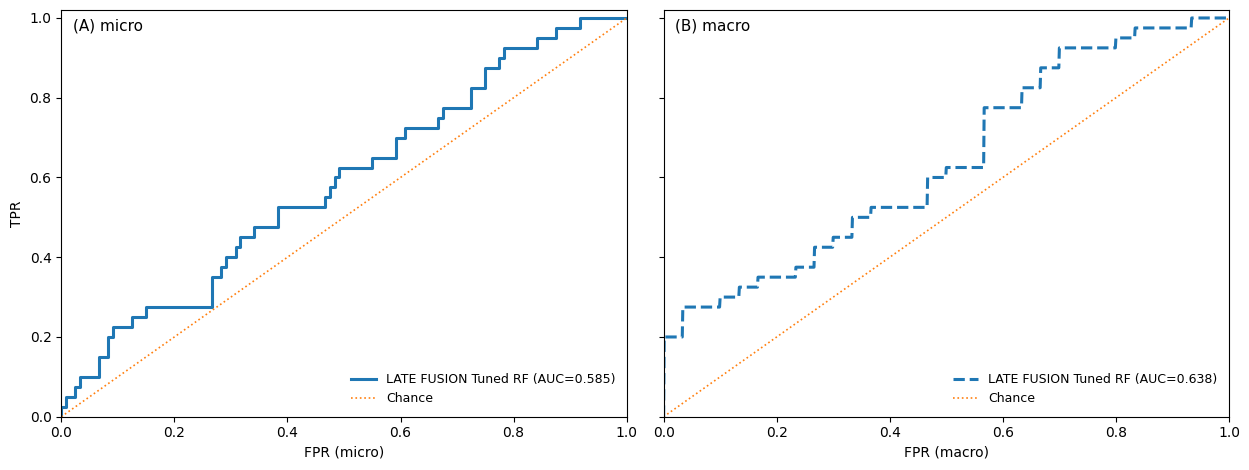

[AUC] train_roc_micro_macro_RF_latefusion_2020 | micro: 1.000000 | macro: 1.000000
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_latefusion_2020.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/train_roc_micro_macro_RF_latefusion_2020.png


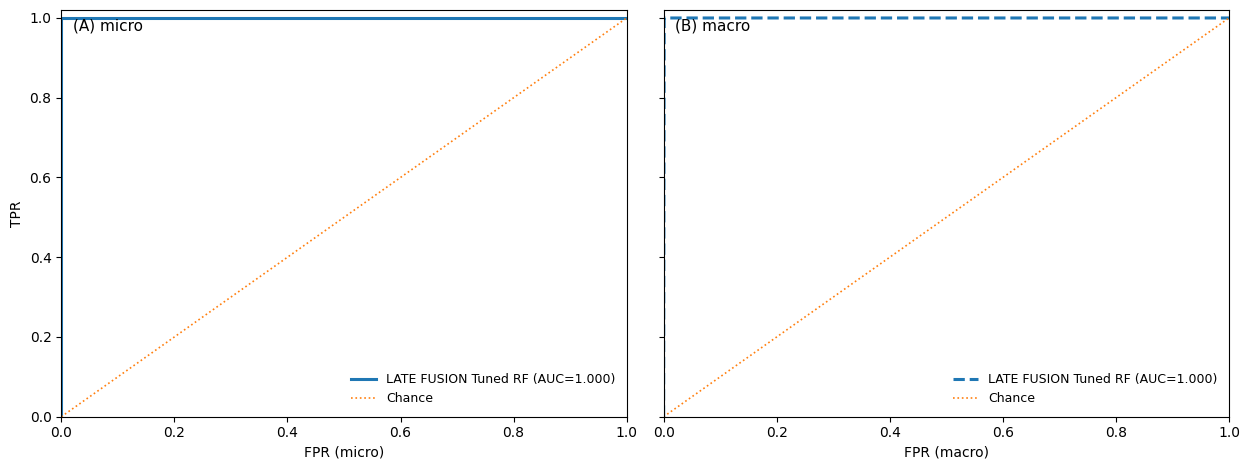


[CHECK] PDFs: ['LATEFUSION_modality_contribution_top20.pdf', 'LATEFUSION_prot_shap_beeswarm_top20.pdf', 'LATEFUSION_prot_shap_global_top20_bar.pdf', 'LATEFUSION_rna_shap_beeswarm_top20.pdf', 'LATEFUSION_rna_shap_global_top20_bar.pdf', 'ROC_synced_with_bar_early_TissueA.pdf', 'fig_confusion_2021_EARLY_FUSION_precision_CROP4.pdf', 'fig_confusion_2021_LATE_FUSION_precision_CROP4.pdf', 'fig_confusion_2021_PROTEIN_precision_CROP4.pdf', 'fig_confusion_2021_RNA_precision_CROP4.pdf', 'fig_precision_recall_per_crop_2021_EARLY_FUSION_CROP4.pdf', 'fig_precision_recall_per_crop_2021_LATE_FUSION_CROP4.pdf', 'fig_precision_recall_per_crop_2021_PROTEIN_CROP4.pdf', 'fig_precision_recall_per_crop_2021_RNA_CROP4.pdf', 'standard_paper_performance_early_TissueA.pdf', 'temporal_valid_roc_micro_macro_RF_earlyfusion_2021.pdf', 'temporal_valid_roc_micro_macro_RF_latefusion_2021.pdf', 'temporal_valid_roc_micro_macro_RF_prot_2021.pdf', 'temporal_valid_roc_micro_macro_RF_rna_2021.pdf', 'train_roc_micro_macro_RF

In [13]:
# ============================================================
# Make paper-style ROC figures using RF tuning
#   - 2 per-omic models: Protein / RNA
#   - 1 early-fusion model: fused_selected_cols AFTER selection
#   - 1 late-fusion model: average of per-omic predicted probabilities
#   - 2 splits: 2021 valid + 2020 train
#   - total = 10 figures
#   - Saves early/late fusion probabilities to Training-Validation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, make_scorer, roc_curve
from sklearn.preprocessing import label_binarize

STAGE1_N_ITER = 80


# ---------- paper figure (two panels) ----------
def paper_micro_macro_roc_figure_from_proba(
    y_int, proba, model_label, out_stem, fig_dir=None, show=True
):
    if fig_dir is None:
        fig_dir = FIG_DIR
    fig_dir = Path(fig_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)

    y = np.asarray(y_int)
    P = np.asarray(proba)
    K = int(P.shape[1])
    classes = np.arange(K)

    Y = label_binarize(y, classes=classes)

    # micro
    fpr_micro, tpr_micro, _ = roc_curve(Y.ravel(), P.ravel())
    auc_micro = roc_auc_score(y, P, multi_class="ovr", average="micro")

    # macro
    all_fpr = np.linspace(0.0, 1.0, 1001)
    tprs = []
    for k in range(K):
        fpr_k, tpr_k, _ = roc_curve(Y[:, k], P[:, k])
        tpr_interp = np.interp(all_fpr, fpr_k, tpr_k)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    tpr_macro = np.mean(np.vstack(tprs), axis=0)
    tpr_macro[-1] = 1.0
    auc_macro = roc_auc_score(y, P, multi_class="ovr", average="macro")

    fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), sharey=True)

    ax = axes[0]
    ax.plot(fpr_micro, tpr_micro, lw=2.2, label=f"{model_label} (AUC={auc_micro:.3f})")
    ax.plot([0, 1], [0, 1], ls=":", lw=1.2, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("FPR (micro)")
    ax.set_ylabel("TPR")
    ax.text(0.02, 0.98, "(A) micro", transform=ax.transAxes, ha="left", va="top", fontsize=11)
    ax.legend(loc="lower right", frameon=False, fontsize=9)

    ax = axes[1]
    ax.plot(all_fpr, tpr_macro, lw=2.2, ls="--", label=f"{model_label} (AUC={auc_macro:.3f})")
    ax.plot([0, 1], [0, 1], ls=":", lw=1.2, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("FPR (macro)")
    ax.text(0.02, 0.98, "(B) macro", transform=ax.transAxes, ha="left", va="top", fontsize=11)
    ax.legend(loc="lower right", frameon=False, fontsize=9)

    fig.tight_layout()

    out_pdf = fig_dir / f"{out_stem}.pdf"
    out_png = fig_dir / f"{out_stem}.png"
    fig.savefig(out_pdf, bbox_inches="tight")
    fig.savefig(out_png, dpi=300, bbox_inches="tight")

    print("[AUC]", out_stem, "| micro:", f"{auc_micro:.6f}", "| macro:", f"{auc_macro:.6f}")
    print("[SAVED]", out_pdf.resolve())
    print("[SAVED]", out_png.resolve())

    if show:
        plt.show()
    plt.close(fig)

    return float(auc_micro), float(auc_macro)


# ---------- RF tuning ----------
def tune_rf_cell3a_style(Xtr_sub, ytr, random_seed, stage1_n_iter=80):
    PARAM_DIST = {
        "n_estimators": randint(150, 650),
        "max_depth": [None, 8, 12],
        "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 8),
        "bootstrap": [True],
        "class_weight": ["balanced"],
        "criterion": ["gini", "entropy"],
    }

    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

    SCORING = make_scorer(
        roc_auc_score,
        needs_proba=True,
        multi_class="ovr",
        average="macro"
    )

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=random_seed, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=stage1_n_iter,
        scoring=SCORING,
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=1,
        refit=True,
    )
    rs.fit(Xtr_sub, ytr)
    return rs.best_estimator_, dict(rs.best_params_), float(rs.best_score_)


# ---------- helper: fit one per-omic RF ----------
def fit_one_omic_rf(omic_key, label_name):
    selected_cols = load_selected_cols_from_csv(SAVE_DIR, mode="per_omic", omic=omic_key)
    Xtr_raw = data_dict_train[omic_key]
    Xva_raw = data_dict_valid[omic_key]

    print(f"\n================ {label_name} RF ================")
    print("[INFO] loaded selected cols:", len(selected_cols))

    Xtr_std, Xva_std = fit_preprocess_train_val(preprocessing, Xtr_raw, Xva_raw)

    sel = [c for c in selected_cols if c in Xtr_std.columns]
    if len(sel) == 0:
        raise ValueError(f"[ERROR] ({label_name}) selected_cols empty after intersect.")

    Xtr_sub = Xtr_std[sel].to_numpy()
    Xva_sub = Xva_std[sel].to_numpy()
    ytr = np.asarray(y_train_enc)

    print("[INFO] Xtr_sub:", Xtr_sub.shape, "Xva_sub:", Xva_sub.shape)

    best_rf, best_params, best_cv = tune_rf_cell3a_style(
        Xtr_sub, ytr, random_seed=RANDOM_SEED, stage1_n_iter=STAGE1_N_ITER
    )
    print(f"[CV] best macro OvR AUC = {best_cv:.4f}")
    print("[CV] best params =", best_params)

    proba_va = best_rf.predict_proba(Xva_sub)
    proba_tr = best_rf.predict_proba(Xtr_sub)

    return {
        "omic": omic_key,
        "label": label_name,
        "best_rf": best_rf,
        "best_params": best_params,
        "best_cv": best_cv,
        "selected_cols_used": sel,
        "proba_va": proba_va,
        "proba_tr": proba_tr,
    }


# ---------- helper: fit EARLY fusion RF AFTER selection ----------
def fit_early_fusion_rf_after_selection():
    fused_cols = load_selected_cols_from_csv(SAVE_DIR, mode="fused")

    Xtr_raw = pd.concat(
        [data_dict_train["prot"], data_dict_train["rna"]],
        axis=1
    )
    Xva_raw = pd.concat(
        [data_dict_valid["prot"], data_dict_valid["rna"]],
        axis=1
    )

    print("\n================ EARLY FUSION RF (AFTER SELECTION) ================")
    print("[INFO] loaded fused selected cols:", len(fused_cols))

    Xtr_std, Xva_std = fit_preprocess_train_val(preprocessing, Xtr_raw, Xva_raw)

    sel = [c for c in fused_cols if c in Xtr_std.columns]
    if len(sel) == 0:
        raise ValueError("[ERROR] (EARLY FUSION) fused selected cols empty after intersect.")

    Xtr_sub = Xtr_std[sel].to_numpy()
    Xva_sub = Xva_std[sel].to_numpy()
    ytr = np.asarray(y_train_enc)

    print("[INFO] Xtr_sub:", Xtr_sub.shape, "Xva_sub:", Xva_sub.shape)

    best_rf, best_params, best_cv = tune_rf_cell3a_style(
        Xtr_sub, ytr, random_seed=RANDOM_SEED, stage1_n_iter=STAGE1_N_ITER
    )
    print(f"[CV] best macro OvR AUC = {best_cv:.4f}")
    print("[CV] best params =", best_params)

    proba_va = best_rf.predict_proba(Xva_sub)
    proba_tr = best_rf.predict_proba(Xtr_sub)

    return {
        "label": "EARLY FUSION",
        "best_rf": best_rf,
        "best_params": best_params,
        "best_cv": best_cv,
        "selected_cols_used": sel,
        "proba_va": proba_va,
        "proba_tr": proba_tr,
        "Xva_index": Xva_std.index,
        "Xtr_index": Xtr_std.index,
    }


# ============================================================
# OUTPUT DIR FOR SAVED PROBAS
# ============================================================
OUT_DIR = Path(results["paths"]["training_validation"])
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# RUN: 3 per-omic models
# ============================================================
omic_specs = [
    ("prot", "PROT", "RF_prot"),
    ("rna",  "RNA",  "RF_rna"),
]

member_outputs = []

for omic_key, label_name, tag in omic_specs:
    out = fit_one_omic_rf(omic_key, label_name)
    member_outputs.append(out)

    # save per-omic valid probas too (optional but convenient)
    pd.DataFrame(
        out["proba_va"],
        index=data_dict_valid[omic_key].index
    ).to_csv(OUT_DIR / f"pred_{omic_key}_valid_proba.csv")

    pd.DataFrame(
        out["proba_tr"],
        index=data_dict_train[omic_key].index
    ).to_csv(OUT_DIR / f"pred_{omic_key}_train_proba.csv")

    paper_micro_macro_roc_figure_from_proba(
        y_int=y_val_enc,
        proba=out["proba_va"],
        model_label=f"{label_name} Tuned RF",
        out_stem=f"temporal_valid_roc_micro_macro_{tag}_2021",
        fig_dir=FIG_DIR,
        show=True,
    )

    paper_micro_macro_roc_figure_from_proba(
        y_int=y_train_enc,
        proba=out["proba_tr"],
        model_label=f"{label_name} Tuned RF",
        out_stem=f"train_roc_micro_macro_{tag}_2020",
        fig_dir=FIG_DIR,
        show=True,
    )


# ============================================================
# EARLY FUSION: AFTER selection
# ============================================================
early_out = fit_early_fusion_rf_after_selection()

proba_va_early = early_out["proba_va"]
proba_tr_early = early_out["proba_tr"]

early_va_df = pd.DataFrame(proba_va_early, index=early_out["Xva_index"])
early_tr_df = pd.DataFrame(proba_tr_early, index=early_out["Xtr_index"])

early_va_path = OUT_DIR / "pred_early_fusion_valid_proba.csv"
early_tr_path = OUT_DIR / "pred_early_fusion_train_proba.csv"

early_va_df.to_csv(early_va_path)
early_tr_df.to_csv(early_tr_path)

print("[SAVED]", early_va_path.resolve())
print("[SAVED]", early_tr_path.resolve())

paper_micro_macro_roc_figure_from_proba(
    y_int=y_val_enc,
    proba=proba_va_early,
    model_label="EARLY FUSION Tuned RF",
    out_stem="temporal_valid_roc_micro_macro_RF_earlyfusion_2021",
    fig_dir=FIG_DIR,
    show=True,
)

paper_micro_macro_roc_figure_from_proba(
    y_int=y_train_enc,
    proba=proba_tr_early,
    model_label="EARLY FUSION Tuned RF",
    out_stem="train_roc_micro_macro_RF_earlyfusion_2020",
    fig_dir=FIG_DIR,
    show=True,
)


# ============================================================
# LATE FUSION: average probabilities across per-omic models
# ============================================================
proba_va_late = np.mean([m["proba_va"] for m in member_outputs], axis=0)
proba_tr_late = np.mean([m["proba_tr"] for m in member_outputs], axis=0)

print("\n================ LATE FUSION RF ================")
print("[INFO] late fusion built by averaging per-omic predicted probabilities")
print("[INFO] validation proba shape:", proba_va_late.shape)
print("[INFO] train proba shape:", proba_tr_late.shape)

late_va_df = pd.DataFrame(
    proba_va_late,
    index=data_dict_valid["prot"].index,
)
late_tr_df = pd.DataFrame(
    proba_tr_late,
    index=data_dict_train["prot"].index,
)

late_va_path = OUT_DIR / "pred_late_fusion_valid_proba.csv"
late_tr_path = OUT_DIR / "pred_late_fusion_train_proba.csv"

late_va_df.to_csv(late_va_path)
late_tr_df.to_csv(late_tr_path)

print("[SAVED]", late_va_path.resolve())
print("[SAVED]", late_tr_path.resolve())

paper_micro_macro_roc_figure_from_proba(
    y_int=y_val_enc,
    proba=proba_va_late,
    model_label="LATE FUSION Tuned RF",
    out_stem="temporal_valid_roc_micro_macro_RF_latefusion_2021",
    fig_dir=FIG_DIR,
    show=True,
)

paper_micro_macro_roc_figure_from_proba(
    y_int=y_train_enc,
    proba=proba_tr_late,
    model_label="LATE FUSION Tuned RF",
    out_stem="train_roc_micro_macro_RF_latefusion_2020",
    fig_dir=FIG_DIR,
    show=True,
)

print("\n[CHECK] PDFs:", sorted([p.name for p in FIG_DIR.glob("*.pdf")]))
print("[CHECK] PNGs:", sorted([p.name for p in FIG_DIR.glob("*.png")]))
print("[CHECK] Saved probas in:", OUT_DIR)

## Optional SHAP dependency refresh

In [14]:
# Run this cell only if SHAP or NumPy/Numba compatibility errors occur in Colab.
!pip -q install -U "numpy<=2.0.999" --force-reinstall
!pip -q install -U shap numba llvmlite


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 106.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stabl 1.0.0 requires adjustText>=0.8, which is not installed.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1

## Late-fusion SHAP summary

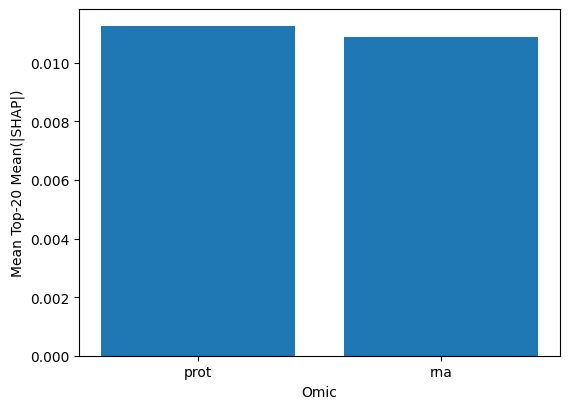

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_modality_contribution_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_modality_contribution_top20.png

[INFO] Late-fusion modality contribution summary:
omic    score
prot 0.011268
 rna 0.010860


/tmp/ipykernel_14089/2202903874.py:198: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


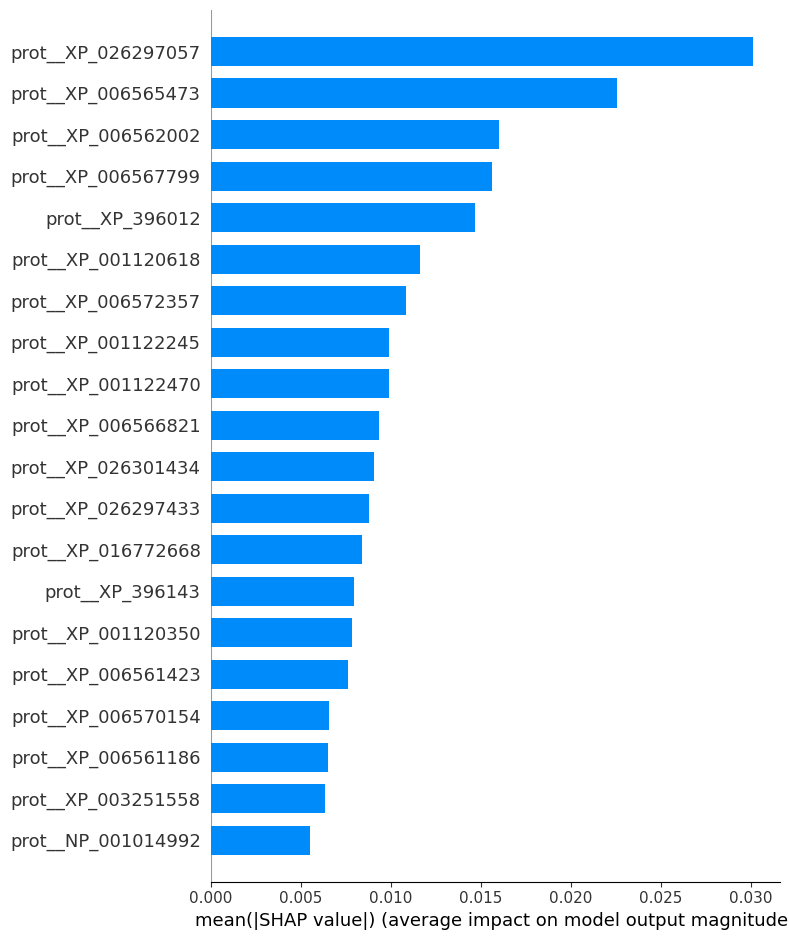

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_prot_shap_global_top20_bar.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_prot_shap_global_top20_bar.png


/tmp/ipykernel_14089/2202903874.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


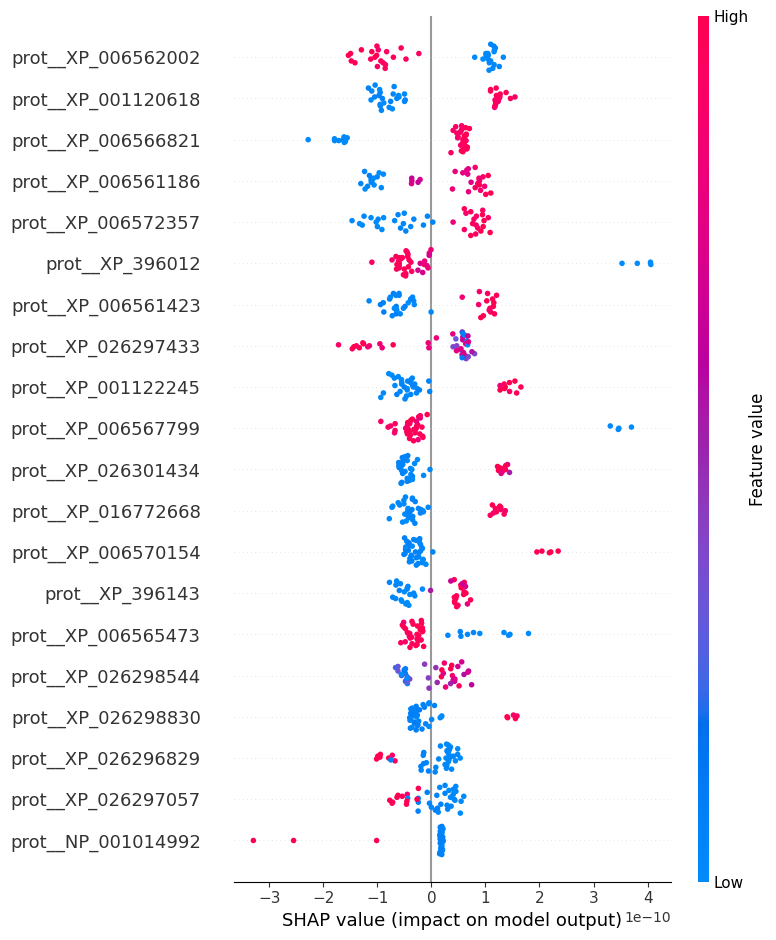

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_prot_shap_beeswarm_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_prot_shap_beeswarm_top20.png

[INFO] PROT Top-20 features:
           feature  mean_abs_shap
prot__XP_026297057       0.030101
prot__XP_006565473       0.022563
prot__XP_006562002       0.016004
prot__XP_006567799       0.015629
   prot__XP_396012       0.014666
prot__XP_001120618       0.011638
prot__XP_006572357       0.010852
prot__XP_001122245       0.009922
prot__XP_001122470       0.009908
prot__XP_006566821       0.009331
prot__XP_026301434       0.009067
prot__XP_026297433       0.008815
prot__XP_016772668       0.008424
   prot__XP_396143       0.007958
prot__XP_001120350       0.007868
prot__XP_006561423       0.007641
prot__XP_006570154       0.006566
prot__XP_006561186       0.006544
prot__XP_003251558       0.006347
prot__NP_001014992       0.005521


/tmp/ipykernel_14089/2202903874.py:198: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


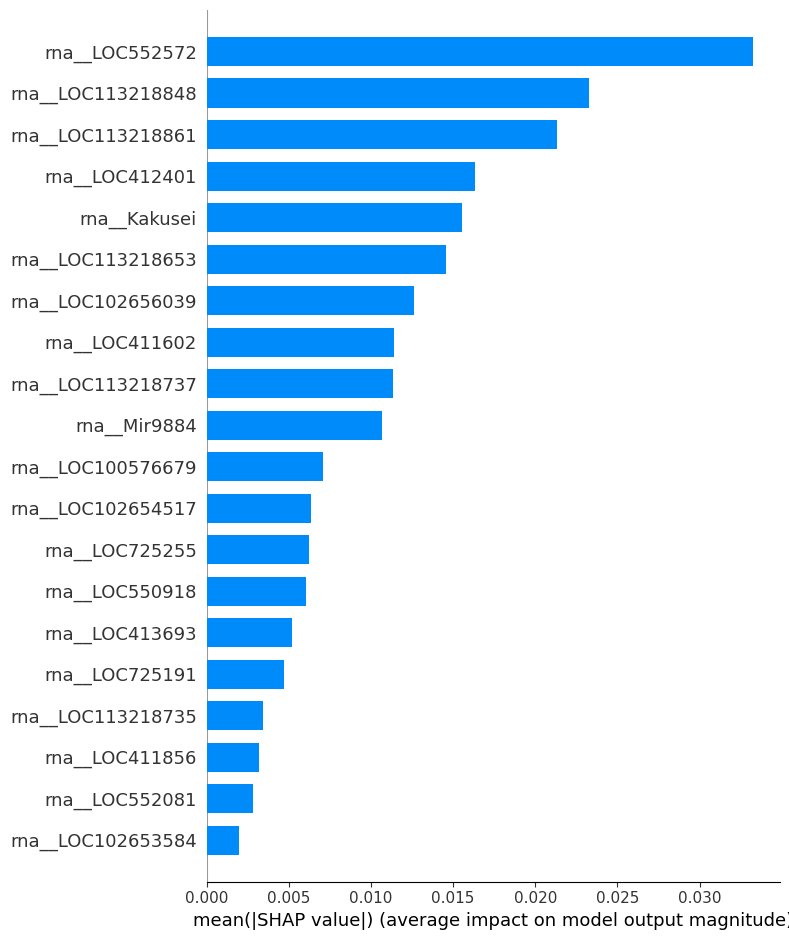

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_rna_shap_global_top20_bar.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_rna_shap_global_top20_bar.png


/tmp/ipykernel_14089/2202903874.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


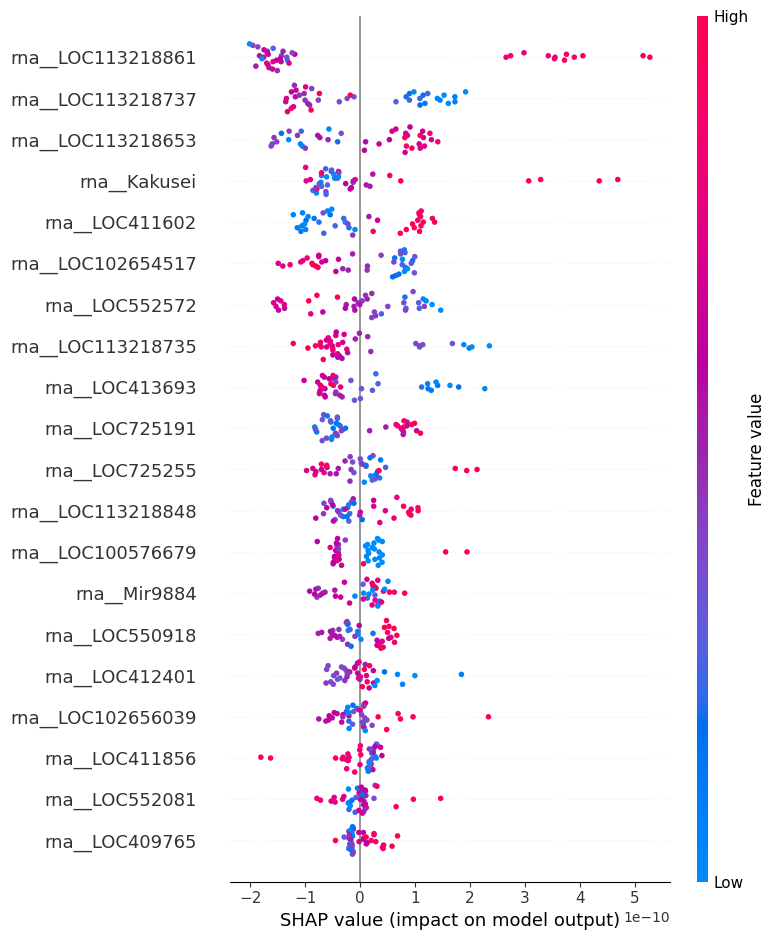

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_rna_shap_beeswarm_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_rna_shap_beeswarm_top20.png

[INFO] RNA Top-20 features:
          feature  mean_abs_shap
   rna__LOC552572       0.033236
rna__LOC113218848       0.023249
rna__LOC113218861       0.021311
   rna__LOC412401       0.016351
     rna__Kakusei       0.015538
rna__LOC113218653       0.014542
rna__LOC102656039       0.012652
   rna__LOC411602       0.011407
rna__LOC113218737       0.011317
     rna__Mir9884       0.010689
rna__LOC100576679       0.007080
rna__LOC102654517       0.006330
   rna__LOC725255       0.006225
   rna__LOC550918       0.006044
   rna__LOC413693       0.005171
   rna__LOC725191       0.004712
rna__LOC113218735       0.003407
   rna__LOC411856       0.003172
   rna__LOC552081       0.002794
rna__LOC102653584       0.001964


In [15]:
# ============================================================
# LATE-FUSION SHAP summary (4 plots total)
#   (A) Modality contribution bar plot (Protein/RNA)
#   (B) PROT global SHAP barh (Top-20)
#   (C) RNA  global SHAP barh (Top-20)
#   (D) Early-fusion global SHAP bar plot (Top-20)
# Saves to FIG_DIR
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

TOP_N = 20
MAX_EVAL = 2000
MAX_BG = 300
RANDOM_STATE = 42

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 0) Collect late-fusion member models and matching eval data
#    Assumes you already ran the late-fusion RF cell and have:
#    - member_outputs: list of dicts with keys ["omic", "best_rf"]
# ------------------------------------------------------------
member_model_map = {m["omic"]: m["best_rf"] for m in member_outputs}

# per-omic eval matrices in the SAME feature space used for each RF
latefusion_inputs = {}

for omic in ["prot", "rna"]:
    selected_cols = load_selected_cols_from_csv(SAVE_DIR, mode="per_omic", omic=omic)

    Xtr_std_i, Xva_std_i = fit_preprocess_train_val(
        preprocessing,
        data_dict_train[omic],
        data_dict_valid[omic],
    )

    sel_i = [c for c in selected_cols if c in Xtr_std_i.columns]
    if len(sel_i) == 0:
        raise ValueError(f"[ERROR] {omic}: selected_cols empty after intersect.")

    latefusion_inputs[omic] = {
        "model": member_model_map[omic],
        "X_eval": Xva_std_i[sel_i].copy(),
        "sel": sel_i,
    }

y = np.asarray(y_val_enc).astype(int)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def _ensure_df(X):
    if isinstance(X, pd.DataFrame):
        return X.copy()
    X = np.asarray(X)
    return pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])

def _compute_shap_tree_multiclass(model, X_df, max_background=300, max_eval=2000, random_state=42):
    rng = np.random.RandomState(random_state)

    # eval subsample
    if len(X_df) > max_eval:
        idx = rng.choice(len(X_df), size=max_eval, replace=False)
        X_used = X_df.iloc[idx].copy()
    else:
        X_used = X_df.copy()

    # background subsample
    if len(X_used) > max_background:
        bidx = rng.choice(len(X_used), size=max_background, replace=False)
        X_bg = X_used.iloc[bidx].copy()
    else:
        X_bg = X_used.copy()

    explainer = shap.TreeExplainer(model, data=X_bg, feature_perturbation="interventional")
    shap_out = explainer.shap_values(X_used)

    # normalize to S: (K, n, d)
    if isinstance(shap_out, list):
        S = np.stack([np.asarray(sk) for sk in shap_out], axis=0)
    else:
        A = np.asarray(shap_out)
        if A.ndim == 3:
            if A.shape[0] == len(X_used) and A.shape[1] == X_used.shape[1]:
                S = np.transpose(A, (2, 0, 1))   # (n,d,K) -> (K,n,d)
            elif A.shape[1] == len(X_used) and A.shape[2] == X_used.shape[1]:
                S = A                             # already (K,n,d)
            else:
                S = np.transpose(A, (2, 0, 1))
        elif A.ndim == 2:
            S = A[None, :, :]
        else:
            raise ValueError(f"Unexpected shap_values shape: {A.shape}")

    return S, X_used

def _global_shap_importance_df(model, X_eval_df, top_n=20, max_bg=300, max_eval=2000, random_state=42):
    X_df = _ensure_df(X_eval_df)
    S, X_used = _compute_shap_tree_multiclass(
        model=model,
        X_df=X_df,
        max_background=max_bg,
        max_eval=max_eval,
        random_state=random_state,
    )

    feature_names = list(X_used.columns)

    mean_abs_per_class = np.mean(np.abs(S), axis=1)   # (K, d)
    global_mean_abs = mean_abs_per_class.mean(axis=0) # (d,)

    imp = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": global_mean_abs
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return imp, S, X_used

# ------------------------------------------------------------
# 1) Compute per-omic SHAP importances
# ------------------------------------------------------------
imp_tables = {}
modality_scores = []

for omic in ["prot", "rna"]:
    model_i = latefusion_inputs[omic]["model"]
    X_eval_i = latefusion_inputs[omic]["X_eval"]

    imp_i, S_i, X_used_i = _global_shap_importance_df(
        model=model_i,
        X_eval_df=X_eval_i,
        top_n=TOP_N,
        max_bg=MAX_BG,
        max_eval=MAX_EVAL,
        random_state=RANDOM_STATE,
    )

    imp_tables[omic] = imp_i

    # modality-level score = mean over top-N global mean |SHAP|
    modality_score = float(imp_i.head(TOP_N)["mean_abs_shap"].mean())
    modality_scores.append((omic, modality_score))

# ------------------------------------------------------------
# 2) Plot (A): modality contribution bar plot
# ------------------------------------------------------------
mod_df = pd.DataFrame(modality_scores, columns=["omic", "score"])
mod_df = mod_df.sort_values("score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(5.8, 4.2))
plt.bar(mod_df["omic"], mod_df["score"])
plt.ylabel(f"Mean Top-{TOP_N} Mean(|SHAP|)")
plt.xlabel("Omic")
plt.tight_layout()

out_pdf = FIG_DIR / f"LATEFUSION_modality_contribution_top{TOP_N}.pdf"
out_png = FIG_DIR / f"LATEFUSION_modality_contribution_top{TOP_N}.png"
plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("[SAVED]", out_pdf)
print("[SAVED]", out_png)
print("\n[INFO] Late-fusion modality contribution summary:")
print(mod_df.to_string(index=False))
# ------------------------------------------------------------
# 3) Plot (B)(C)(D): per-omic global SHAP
#    - save BOTH:
#      (i) SHAP-style bar plot
#      (ii) beeswarm plot
# ------------------------------------------------------------
for omic in ["prot", "rna"]:
    model_i = latefusion_inputs[omic]["model"]
    X_eval_i = latefusion_inputs[omic]["X_eval"]

    imp_i, S_i, X_used_i = _global_shap_importance_df(
        model=model_i,
        X_eval_df=X_eval_i,
        top_n=TOP_N,
        max_bg=MAX_BG,
        max_eval=MAX_EVAL,
        random_state=RANDOM_STATE,
    )

    # ----------------------------
    # (i) SHAP-style global bar plot
    # ----------------------------
    # Use abs-averaged SHAP across classes, then let SHAP render bar style
    S_bar = np.mean(np.abs(S_i), axis=0)   # (n, d)

    plt.figure(figsize=(7.2, 5.2))
    shap.summary_plot(
        S_bar,
        X_used_i,
        feature_names=list(X_used_i.columns),
        plot_type="bar",
        max_display=TOP_N,
        show=False
    )
    plt.tight_layout()

    out_pdf_bar = FIG_DIR / f"LATEFUSION_{omic}_shap_global_top{TOP_N}_bar.pdf"
    out_png_bar = FIG_DIR / f"LATEFUSION_{omic}_shap_global_top{TOP_N}_bar.png"
    plt.savefig(out_pdf_bar, bbox_inches="tight")
    plt.savefig(out_png_bar, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_pdf_bar)
    print("[SAVED]", out_png_bar)

    # ----------------------------
    # (ii) beeswarm plot
    # ----------------------------
    # Use signed average across classes for beeswarm-style display
    S_bee = np.mean(S_i, axis=0)   # (n, d)

    plt.figure(figsize=(7.2, 5.2))
    shap.summary_plot(
        S_bee,
        X_used_i,
        feature_names=list(X_used_i.columns),
        max_display=TOP_N,
        show=False
    )
    plt.tight_layout()

    out_pdf_bee = FIG_DIR / f"LATEFUSION_{omic}_shap_beeswarm_top{TOP_N}.pdf"
    out_png_bee = FIG_DIR / f"LATEFUSION_{omic}_shap_beeswarm_top{TOP_N}.png"
    plt.savefig(out_pdf_bee, bbox_inches="tight")
    plt.savefig(out_png_bee, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_pdf_bee)
    print("[SAVED]", out_png_bee)

    print(f"\n[INFO] {omic.upper()} Top-{TOP_N} features:")
    print(imp_i.head(TOP_N).to_string(index=False))

# optional
latefusion_global_tables = imp_tables
modality_contribution_table = mod_df

## Modality-contribution figure

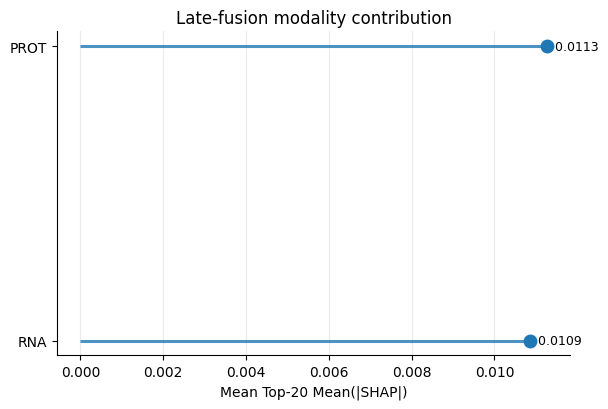

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_modality_contribution_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/LATEFUSION_modality_contribution_top20.png

[INFO] Late-fusion modality contribution summary:
omic    score
prot 0.011268
 rna 0.010860


In [16]:
# ------------------------------------------------------------
# 2) Plot (A): modality contribution plot (SHAP-style lollipop)
# ------------------------------------------------------------
mod_df = pd.DataFrame(modality_scores, columns=["omic", "score"])
mod_df = mod_df.sort_values("score", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6.2, 4.2))

ypos = np.arange(len(mod_df))
ax.hlines(y=ypos, xmin=0, xmax=mod_df["score"], linewidth=2.2, alpha=0.8)
ax.plot(mod_df["score"], ypos, "o", markersize=9)

ax.set_yticks(ypos)
ax.set_yticklabels(mod_df["omic"].str.upper())
ax.set_xlabel(f"Mean Top-{TOP_N} Mean(|SHAP|)")
ax.set_ylabel("")
ax.set_title("Late-fusion modality contribution")
ax.grid(axis="x", alpha=0.25)

for i, v in enumerate(mod_df["score"]):
    ax.text(v, i, f"  {v:.4f}", va="center", fontsize=9)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

out_pdf = FIG_DIR / f"LATEFUSION_modality_contribution_top{TOP_N}.pdf"
out_png = FIG_DIR / f"LATEFUSION_modality_contribution_top{TOP_N}.png"
plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("[SAVED]", out_pdf)
print("[SAVED]", out_png)
print("\n[INFO] Late-fusion modality contribution summary:")
print(mod_df.sort_values('score', ascending=False).to_string(index=False))

## Performance summary bar plot

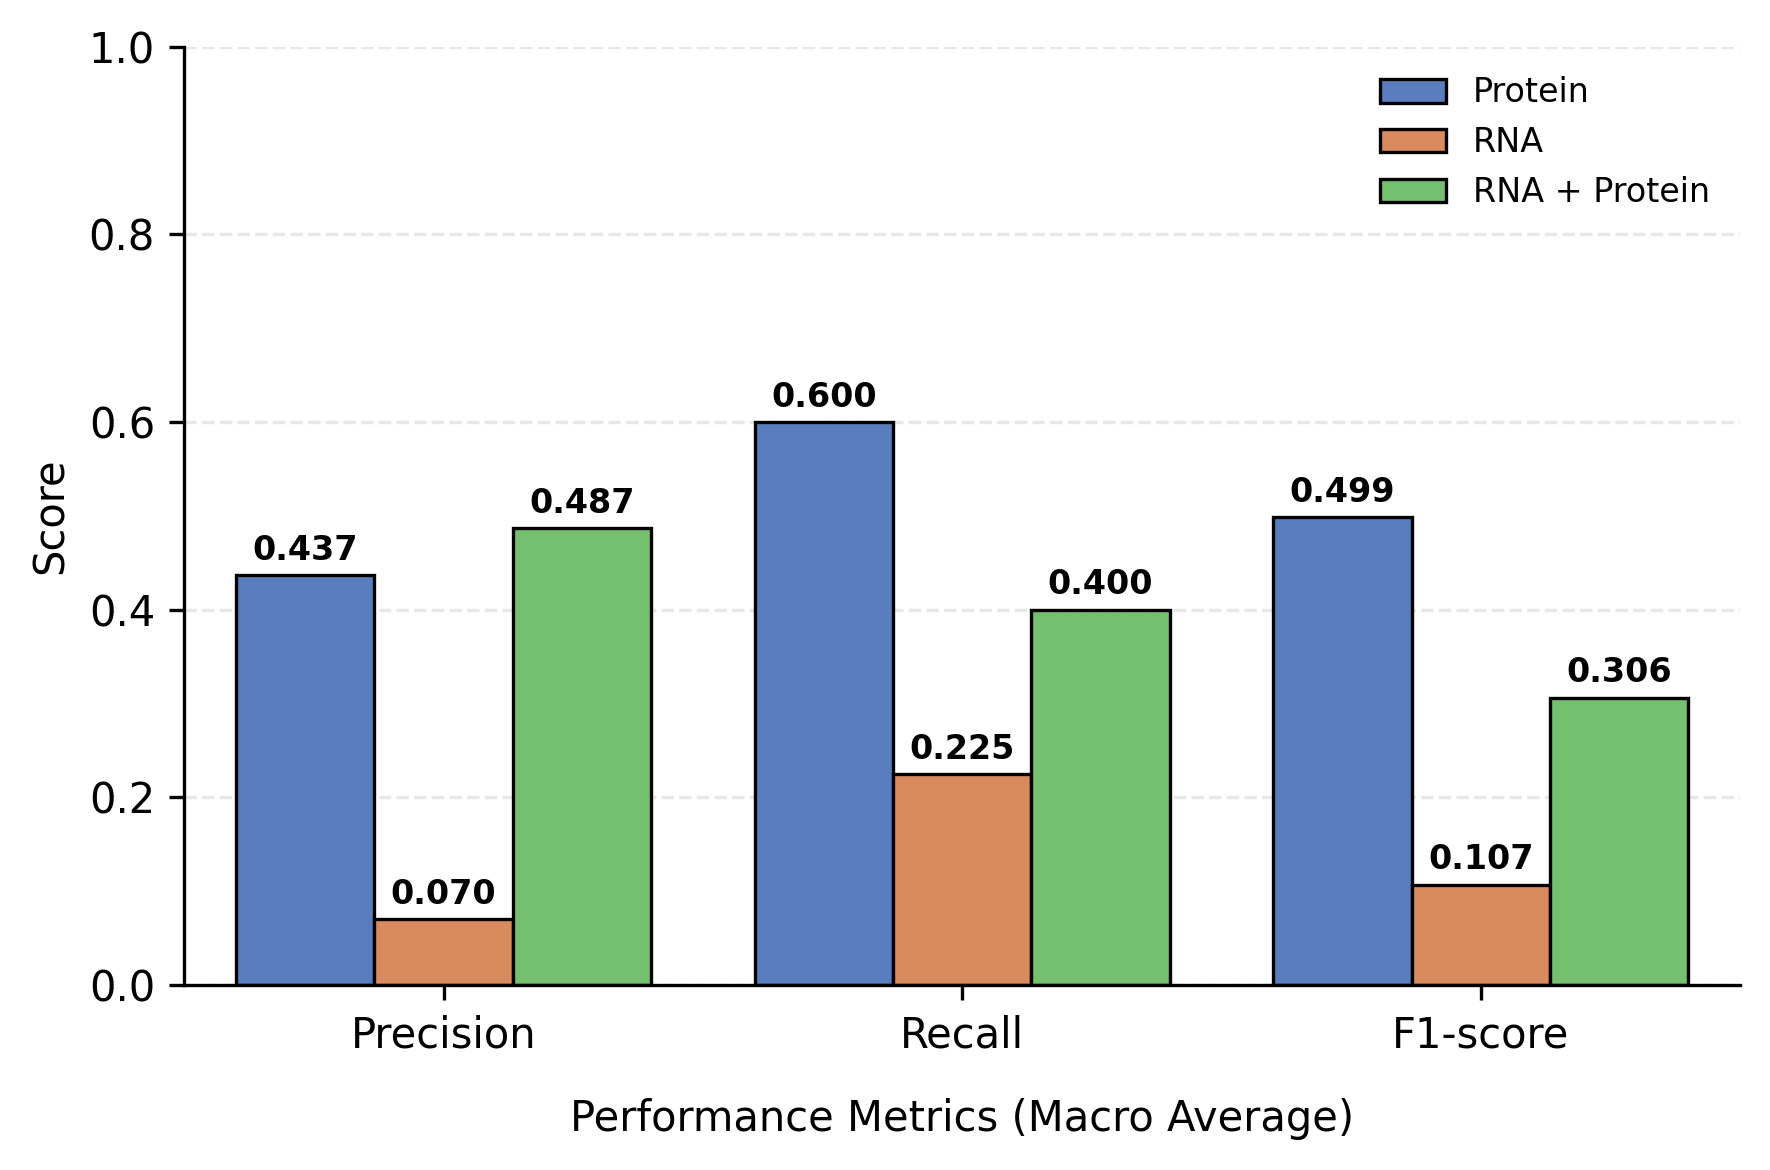

[SUCCESS] In-memory RF metrics figure saved to: /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/standard_paper_performance_early_TissueA.pdf


In [17]:
# ============================================================
# Paper-style 6x4 summary bar plot using in-memory RF probabilities
# - EARLY FUSION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.metrics import precision_recall_fscore_support

# 1. Configure plotting style and fonts
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'Liberation Sans']
rcParams['axes.unicode_minus'] = False

tissue_id = "TissueA"

# 2. Reuse the RF outputs generated in the previous cell
y_true = np.asarray(y_val_enc, dtype=int)
labels_fixed = np.arange(len(np.unique(y_true)))  # Fix the number of classes (K)

plot_data = []

# (A) Protein and RNA models from member_outputs
for m in member_outputs:
    omic = m["omic"]
    label_name = "Protein" if omic == "prot" else "RNA"

    # Use the predicted probabilities generated by the RF model
    proba_va = m["proba_va"]
    y_pred = np.argmax(proba_va, axis=1)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_fixed, average=None, zero_division=0
    )

    plot_data.append({'Modality': label_name, 'Metric': 'Precision', 'Score': np.mean(p)})
    plot_data.append({'Modality': label_name, 'Metric': 'Recall', 'Score': np.mean(r)})
    plot_data.append({'Modality': label_name, 'Metric': 'F1-score', 'Score': np.mean(f1)})

# (B) Early-fusion model
# Keep this variable aligned with the early-fusion RF probability variable created above.
# Example names: proba_va_early, proba_early_va, early_fusion_proba_va.
proba_va_early = proba_va_early

y_pred_early = np.argmax(proba_va_early, axis=1)

p, r, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_early, labels=labels_fixed, average=None, zero_division=0
)

plot_data.append({'Modality': 'RNA + Protein', 'Metric': 'Precision', 'Score': np.mean(p)})
plot_data.append({'Modality': 'RNA + Protein', 'Metric': 'Recall', 'Score': np.mean(r)})
plot_data.append({'Modality': 'RNA + Protein', 'Metric': 'F1-score', 'Score': np.mean(f1)})

df_metrics = pd.DataFrame(plot_data)

# 3. Create a 6x4 inch figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
palette = sns.color_palette("muted", n_colors=3)

sns.barplot(
    data=df_metrics,
    x='Metric',
    y='Score',
    hue='Modality',
    palette=palette,
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)

# Annotate each bar with its score
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8, fontweight='bold')

# Fix the y-axis to 1.0 and place the legend inside the upper-right corner
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.legend(loc='upper right', frameon=False, ncol=1, fontsize=8)

# Axis labels and final styling
ax.set_xlabel('Performance Metrics (Macro Average)', fontsize=10, labelpad=10)
ax.set_ylabel('Score', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

# Save as PDF
output_path = FIG_DIR / f"standard_paper_performance_early_{tissue_id}.pdf"
plt.savefig(output_path, bbox_inches='tight', format='pdf')
plt.show()

print(f"[SUCCESS] In-memory RF metrics figure saved to: {output_path}")

## Early-fusion ROC comparison figure

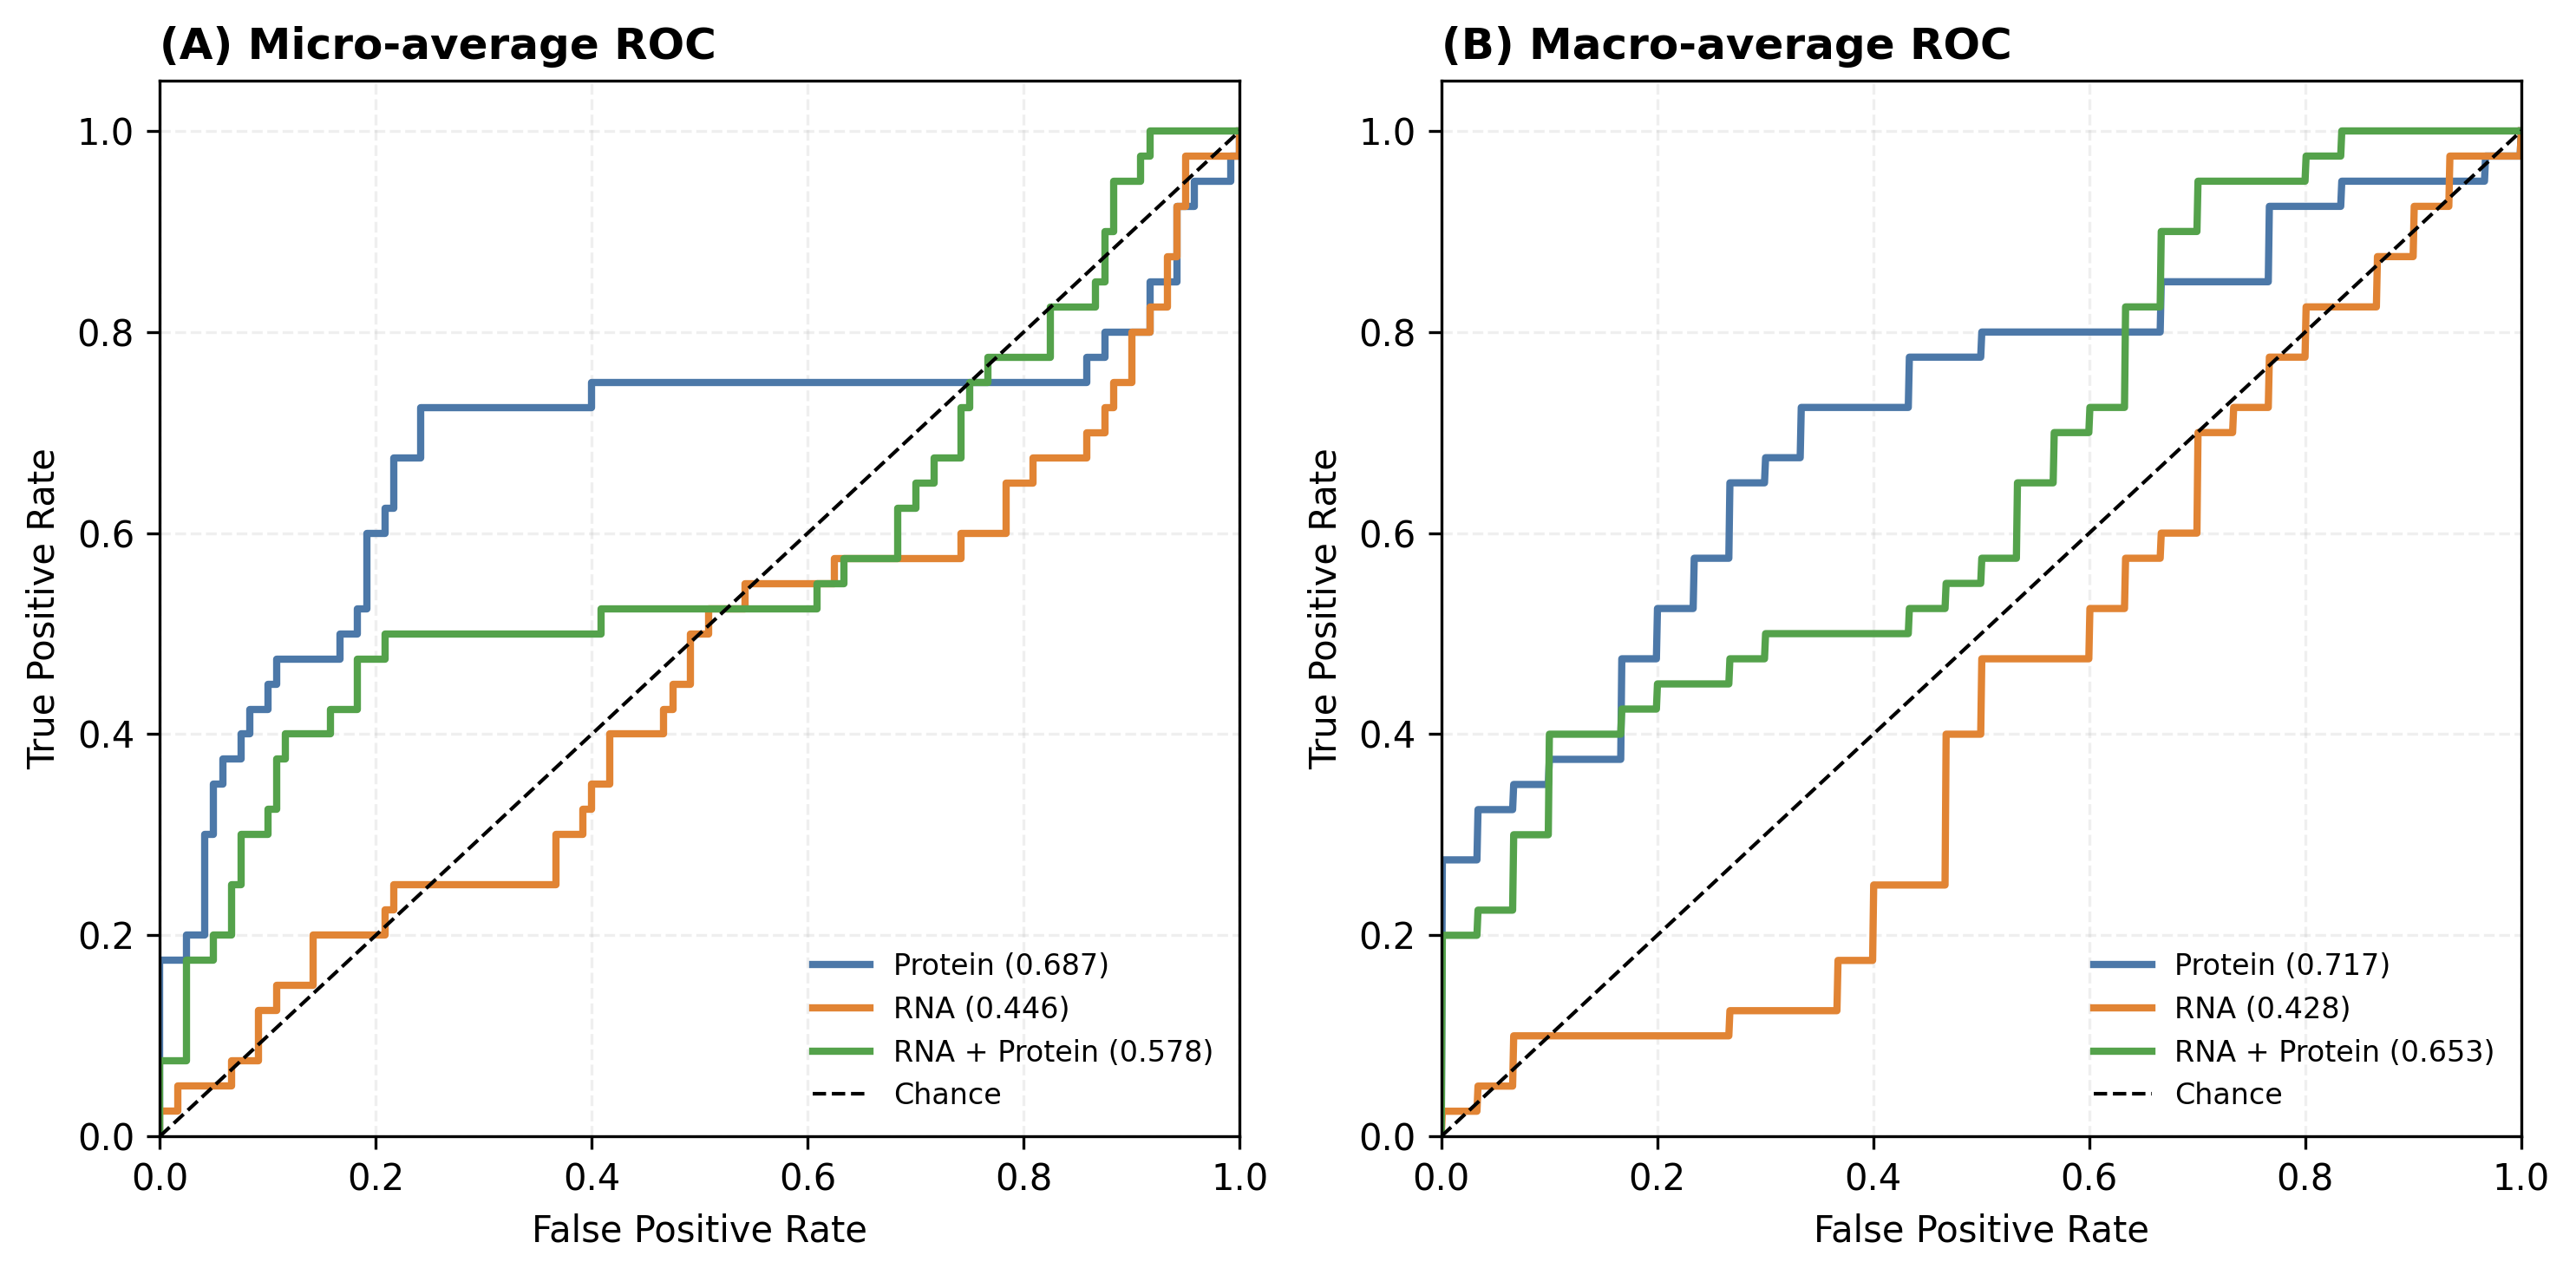

[SUCCESS] Synced EARLY ROC plot (10x5) saved to: /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_A/ROC_synced_with_bar_early_TissueA.pdf


In [18]:
# ============================================================
# Paper-style ROC comparison plot synchronized with the bar-plot style
# - EARLY FUSION VERSION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Prepare data
y_test = np.asarray(y_val_enc)
n_classes = len(le.classes_)
classes = np.arange(n_classes)
Y_bin = label_binarize(y_test, classes=classes)

# Build a probability map from member_outputs
member_map = {m["omic"]: m["proba_va"] for m in member_outputs}

# Set the early-fusion probability variable
# The variable on the right can be changed if the early-fusion probability name changes.
proba_early = proba_va_early

# --- Keep the same colors, order, and labels as the summary bar plot ---
# Protein: Blue (#4C78A8), RNA: Orange (#E18434), Fusion: Green (#54A24B)
plot_configs = [
    {"proba": member_map.get("prot"), "label": "Protein",                     "color": "#4C78A8"},
    {"proba": member_map.get("rna"),  "label": "RNA",                         "color": "#E18434"},
    {"proba": proba_early,            "label": "RNA + Protein", "color": "#54A24B"}
]

# 2. Create the figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)
lw = 2

for config in plot_configs:
    P = config["proba"]
    if P is None:
        continue

    color = config["color"]
    label = config["label"]

    # --- (Panel A) Micro-average ROC ---
    fpr_micro, tpr_micro, _ = roc_curve(Y_bin.ravel(), P.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    axes[0].plot(
        fpr_micro, tpr_micro,
        color=color, lw=lw,
        label=f'{label} ({roc_auc_micro:.3f})'
    )

    # --- (Panel B) Macro-average ROC ---
    all_fpr = np.linspace(0.0, 1.0, 1000)
    mean_tpr = 0.0
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(Y_bin[:, i], P[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)

    mean_tpr /= n_classes
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0
    roc_auc_macro = auc(all_fpr, mean_tpr)

    axes[1].plot(
        all_fpr, mean_tpr,
        color=color, lw=lw,
        label=f'{label} ({roc_auc_macro:.3f})'
    )

# 3. Final styling
titles = ["(A) Micro-average ROC", "(B) Macro-average ROC"]
for i, ax in enumerate(axes):
    ax.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(titles[i], fontsize=12, fontweight='bold', loc='left')
    ax.legend(loc="lower right", frameon=False, fontsize=8)
    ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()

# Save the figure
output_roc_path = FIG_DIR / f"ROC_synced_with_bar_early_{tissue_id}.pdf"
plt.savefig(output_roc_path, bbox_inches='tight', format='pdf')
plt.show()

print(f"[SUCCESS] Synced EARLY ROC plot (10x5) saved to: {output_roc_path}")

## Confusion matrix and per-class metrics: early fusion

[INFO] Using In-Memory Early Fusion Proba...


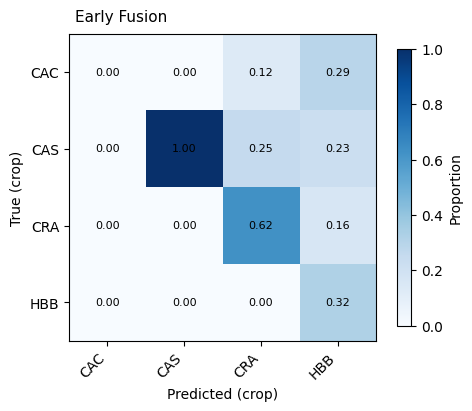

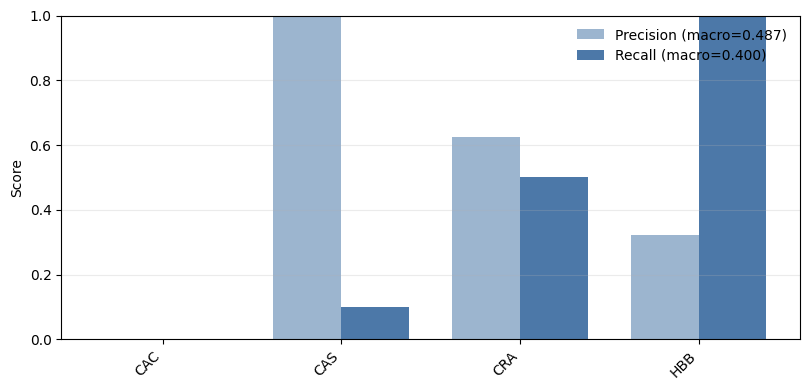

In [19]:
# ============================================================
# 4-class (CROP) — EARLY FUSION
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_score, recall_score

CMAP = "Blues"
COLOR_MODEL = "#4C78A8" # Early Fusion = Blue
GRID_ALPHA = 0.25

y_true = np.asarray(y_val_enc, dtype=int)

# ----------------------------
# 1) Load EARLY FUSION probabilities from the in-memory variables above
# ----------------------------
print("[INFO] Using In-Memory Early Fusion Proba...")
P = np.asarray(early_out["proba_va"])
yhat = np.asarray(np.argmax(P, axis=1), dtype=int)

# ----------------------------
# 2) Class labels & Helpers
# ----------------------------
if "le" in globals() and hasattr(le, "classes_"):
    class_labels = [str(x) for x in le.classes_]
else:
    class_labels = [f"class_{k}" for k in range(int(np.max(y_true)) + 1)]

K = len(class_labels)
labels = np.arange(K)

def col_normalize(cm):
    return cm / np.maximum(cm.sum(axis=0, keepdims=True), 1)

def plot_cm(ax, cm_norm, panel_label):
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap=CMAP)
    ax.set_xticks(np.arange(K))
    ax.set_yticks(np.arange(K))
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted (crop)")
    ax.set_ylabel("True (crop)")
    ax.text(0.02, 1.03, panel_label, transform=ax.transAxes, ha="left", va="bottom", fontsize=11)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
    return im

# ----------------------------
# (1) Confusion matrix
# ----------------------------
cm = confusion_matrix(y_true, yhat, labels=labels)
cm_norm = col_normalize(cm)

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.0), constrained_layout=True)
im = plot_cm(ax, cm_norm, "Early Fusion")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("Proportion")

out_pdf = FIG_DIR / "fig_confusion_2021_EARLY_FUSION_precision_CROP4.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

# ----------------------------
# (2) Per-class Precision + Recall bar plot
# ----------------------------
prec = precision_score(y_true, yhat, average=None, labels=labels, zero_division=0)
rec  = recall_score(y_true, yhat,    average=None, labels=labels, zero_division=0)
macro_prec = float(precision_score(y_true, yhat, average="macro", zero_division=0))
macro_rec  = float(recall_score(y_true, yhat,    average="macro", zero_division=0))

x = np.arange(K)
width = 0.38

fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.bar(x - width/2, prec, width, color=COLOR_MODEL, alpha=0.55, label=f"Precision (macro={macro_prec:.3f})")
ax.bar(x + width/2, rec,  width, color=COLOR_MODEL, alpha=1.00, label=f"Recall (macro={macro_rec:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=GRID_ALPHA)
ax.legend(frameon=False)

fig.tight_layout()
out_pdf_bar = FIG_DIR / "fig_precision_recall_per_crop_2021_EARLY_FUSION_CROP4.pdf"
fig.savefig(out_pdf_bar, bbox_inches="tight")
plt.show()
plt.close(fig)

## Confusion matrix and per-class metrics: late fusion

[INFO] Using In-Memory Late Fusion Proba...


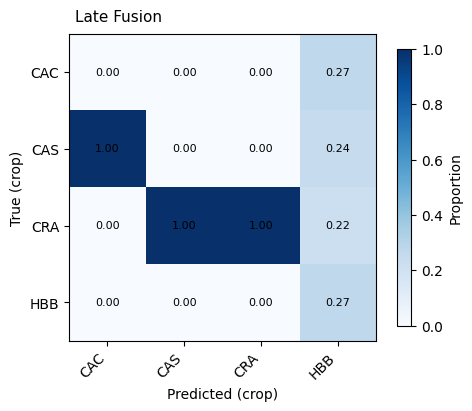

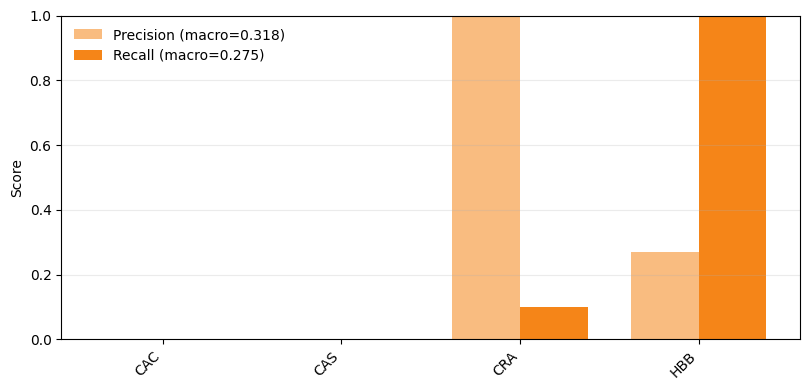

In [20]:
# ============================================================
# 4-class (CROP) — LATE FUSION
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_score, recall_score

CMAP = "Blues"
COLOR_MODEL = "#F58518" # Late Fusion = Orange
GRID_ALPHA = 0.25

y_true = np.asarray(y_val_enc, dtype=int)

# ----------------------------
# 1) Load LATE FUSION probabilities from the in-memory variables above
# ----------------------------
print("[INFO] Using In-Memory Late Fusion Proba...")
P = np.asarray(proba_va_late)
yhat = np.asarray(np.argmax(P, axis=1), dtype=int)

# ----------------------------
# 2) Class labels & Helpers
# ----------------------------
if "le" in globals() and hasattr(le, "classes_"):
    class_labels = [str(x) for x in le.classes_]
else:
    class_labels = [f"class_{k}" for k in range(int(np.max(y_true)) + 1)]

K = len(class_labels)
labels = np.arange(K)

def col_normalize(cm):
    return cm / np.maximum(cm.sum(axis=0, keepdims=True), 1)

def plot_cm(ax, cm_norm, panel_label):
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap=CMAP)
    ax.set_xticks(np.arange(K))
    ax.set_yticks(np.arange(K))
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted (crop)")
    ax.set_ylabel("True (crop)")
    ax.text(0.02, 1.03, panel_label, transform=ax.transAxes, ha="left", va="bottom", fontsize=11)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
    return im

# ----------------------------
# (1) Confusion matrix
# ----------------------------
cm = confusion_matrix(y_true, yhat, labels=labels)
cm_norm = col_normalize(cm)

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.0), constrained_layout=True)
im = plot_cm(ax, cm_norm, "Late Fusion")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("Proportion")

out_pdf = FIG_DIR / "fig_confusion_2021_LATE_FUSION_precision_CROP4.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

# ----------------------------
# (2) Per-class Precision + Recall bar plot
# ----------------------------
prec = precision_score(y_true, yhat, average=None, labels=labels, zero_division=0)
rec  = recall_score(y_true, yhat,    average=None, labels=labels, zero_division=0)
macro_prec = float(precision_score(y_true, yhat, average="macro", zero_division=0))
macro_rec  = float(recall_score(y_true, yhat,    average="macro", zero_division=0))

x = np.arange(K)
width = 0.38

fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.bar(x - width/2, prec, width, color=COLOR_MODEL, alpha=0.55, label=f"Precision (macro={macro_prec:.3f})")
ax.bar(x + width/2, rec,  width, color=COLOR_MODEL, alpha=1.00, label=f"Recall (macro={macro_rec:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=GRID_ALPHA)
ax.legend(frameon=False)

fig.tight_layout()
out_pdf_bar = FIG_DIR / "fig_precision_recall_per_crop_2021_LATE_FUSION_CROP4.pdf"
fig.savefig(out_pdf_bar, bbox_inches="tight")
plt.show()
plt.close(fig)

## Confusion matrix and per-class metrics: protein

[INFO] Using In-Memory Protein Proba...


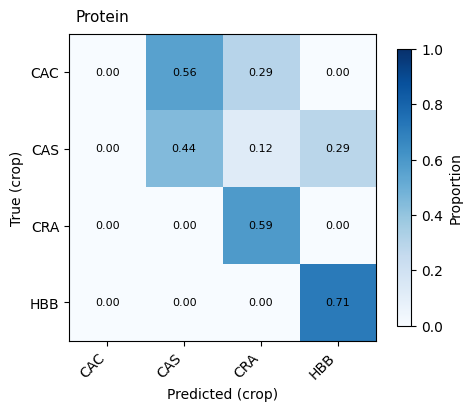

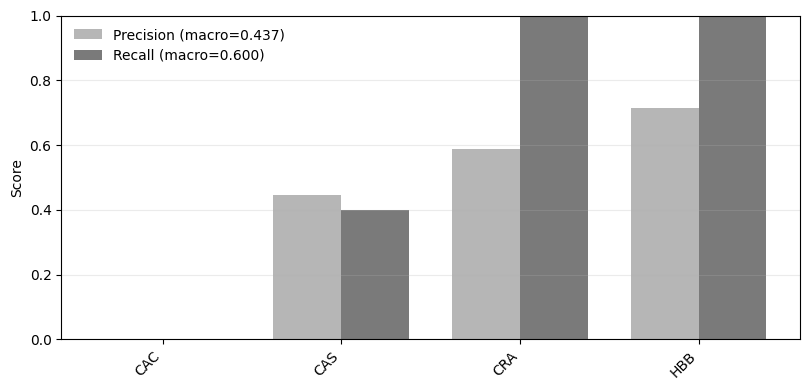

In [21]:
# ============================================================
# 4-class (CROP) — PROTEIN
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_score, recall_score

CMAP = "Blues"
COLOR_MODEL = "#7A7A7A" # Protein = Gray
GRID_ALPHA = 0.25

y_true = np.asarray(y_val_enc, dtype=int)

# ----------------------------
# 1) Load PROTEIN probabilities from the in-memory variables above
# ----------------------------
print("[INFO] Using In-Memory Protein Proba...")
P = None
for m in member_outputs:
    if m["omic"] == "prot":
        P = np.asarray(m["proba_va"])
        break

yhat = np.asarray(np.argmax(P, axis=1), dtype=int)

# ----------------------------
# 2) Class labels & Helpers
# ----------------------------
if "le" in globals() and hasattr(le, "classes_"):
    class_labels = [str(x) for x in le.classes_]
else:
    class_labels = [f"class_{k}" for k in range(int(np.max(y_true)) + 1)]

K = len(class_labels)
labels = np.arange(K)

def col_normalize(cm):
    return cm / np.maximum(cm.sum(axis=0, keepdims=True), 1)

def plot_cm(ax, cm_norm, panel_label):
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap=CMAP)
    ax.set_xticks(np.arange(K))
    ax.set_yticks(np.arange(K))
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted (crop)")
    ax.set_ylabel("True (crop)")
    ax.text(0.02, 1.03, panel_label, transform=ax.transAxes, ha="left", va="bottom", fontsize=11)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
    return im

# ----------------------------
# (1) Confusion matrix
# ----------------------------
cm = confusion_matrix(y_true, yhat, labels=labels)
cm_norm = col_normalize(cm)

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.0), constrained_layout=True)
im = plot_cm(ax, cm_norm, "Protein")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("Proportion")

out_pdf = FIG_DIR / "fig_confusion_2021_PROTEIN_precision_CROP4.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

# ----------------------------
# (2) Per-class Precision + Recall bar plot
# ----------------------------
prec = precision_score(y_true, yhat, average=None, labels=labels, zero_division=0)
rec  = recall_score(y_true, yhat,    average=None, labels=labels, zero_division=0)
macro_prec = float(precision_score(y_true, yhat, average="macro", zero_division=0))
macro_rec  = float(recall_score(y_true, yhat,    average="macro", zero_division=0))

x = np.arange(K)
width = 0.38

fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.bar(x - width/2, prec, width, color=COLOR_MODEL, alpha=0.55, label=f"Precision (macro={macro_prec:.3f})")
ax.bar(x + width/2, rec,  width, color=COLOR_MODEL, alpha=1.00, label=f"Recall (macro={macro_rec:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=GRID_ALPHA)
ax.legend(frameon=False)

fig.tight_layout()
out_pdf_bar = FIG_DIR / "fig_precision_recall_per_crop_2021_PROTEIN_CROP4.pdf"
fig.savefig(out_pdf_bar, bbox_inches="tight")
plt.show()
plt.close(fig)

## Confusion matrix and per-class metrics: RNA

[INFO] Using In-Memory RNA Proba...


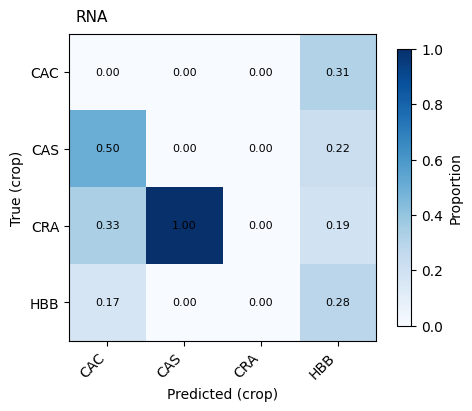

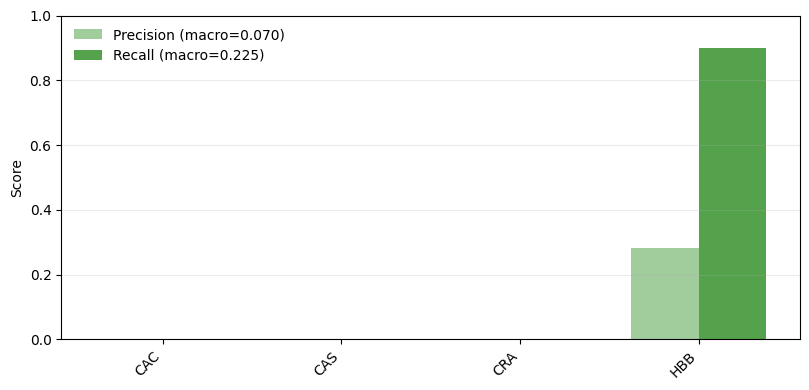

In [22]:
# ============================================================
# 4-class (CROP) — RNA
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_score, recall_score

CMAP = "Blues"
COLOR_MODEL = "#54A24B" # RNA = Green
GRID_ALPHA = 0.25

y_true = np.asarray(y_val_enc, dtype=int)

# ----------------------------
# 1) Load RNA probabilities from the in-memory variables above
# ----------------------------
print("[INFO] Using In-Memory RNA Proba...")
P = None
for m in member_outputs:
    if m["omic"] == "rna":
        P = np.asarray(m["proba_va"])
        break

yhat = np.asarray(np.argmax(P, axis=1), dtype=int)

# ----------------------------
# 2) Class labels & Helpers
# ----------------------------
if "le" in globals() and hasattr(le, "classes_"):
    class_labels = [str(x) for x in le.classes_]
else:
    class_labels = [f"class_{k}" for k in range(int(np.max(y_true)) + 1)]

K = len(class_labels)
labels = np.arange(K)

def col_normalize(cm):
    return cm / np.maximum(cm.sum(axis=0, keepdims=True), 1)

def plot_cm(ax, cm_norm, panel_label):
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap=CMAP)
    ax.set_xticks(np.arange(K))
    ax.set_yticks(np.arange(K))
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted (crop)")
    ax.set_ylabel("True (crop)")
    ax.text(0.02, 1.03, panel_label, transform=ax.transAxes, ha="left", va="bottom", fontsize=11)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
    return im

# ----------------------------
# (1) Confusion matrix
# ----------------------------
cm = confusion_matrix(y_true, yhat, labels=labels)
cm_norm = col_normalize(cm)

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.0), constrained_layout=True)
im = plot_cm(ax, cm_norm, "RNA")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("Proportion")

out_pdf = FIG_DIR / "fig_confusion_2021_RNA_precision_CROP4.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

# ----------------------------
# (2) Per-class Precision + Recall bar plot
# ----------------------------
prec = precision_score(y_true, yhat, average=None, labels=labels, zero_division=0)
rec  = recall_score(y_true, yhat,    average=None, labels=labels, zero_division=0)
macro_prec = float(precision_score(y_true, yhat, average="macro", zero_division=0))
macro_rec  = float(recall_score(y_true, yhat,    average="macro", zero_division=0))

x = np.arange(K)
width = 0.38

fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.bar(x - width/2, prec, width, color=COLOR_MODEL, alpha=0.55, label=f"Precision (macro={macro_prec:.3f})")
ax.bar(x + width/2, rec,  width, color=COLOR_MODEL, alpha=1.00, label=f"Recall (macro={macro_rec:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=GRID_ALPHA)
ax.legend(frameon=False)

fig.tight_layout()
out_pdf_bar = FIG_DIR / "fig_precision_recall_per_crop_2021_RNA_CROP4.pdf"
fig.savefig(out_pdf_bar, bbox_inches="tight")
plt.show()
plt.close(fig)

## Paper-style SHAP feature-importance figures

[INFO] SHAP_DIR: /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper


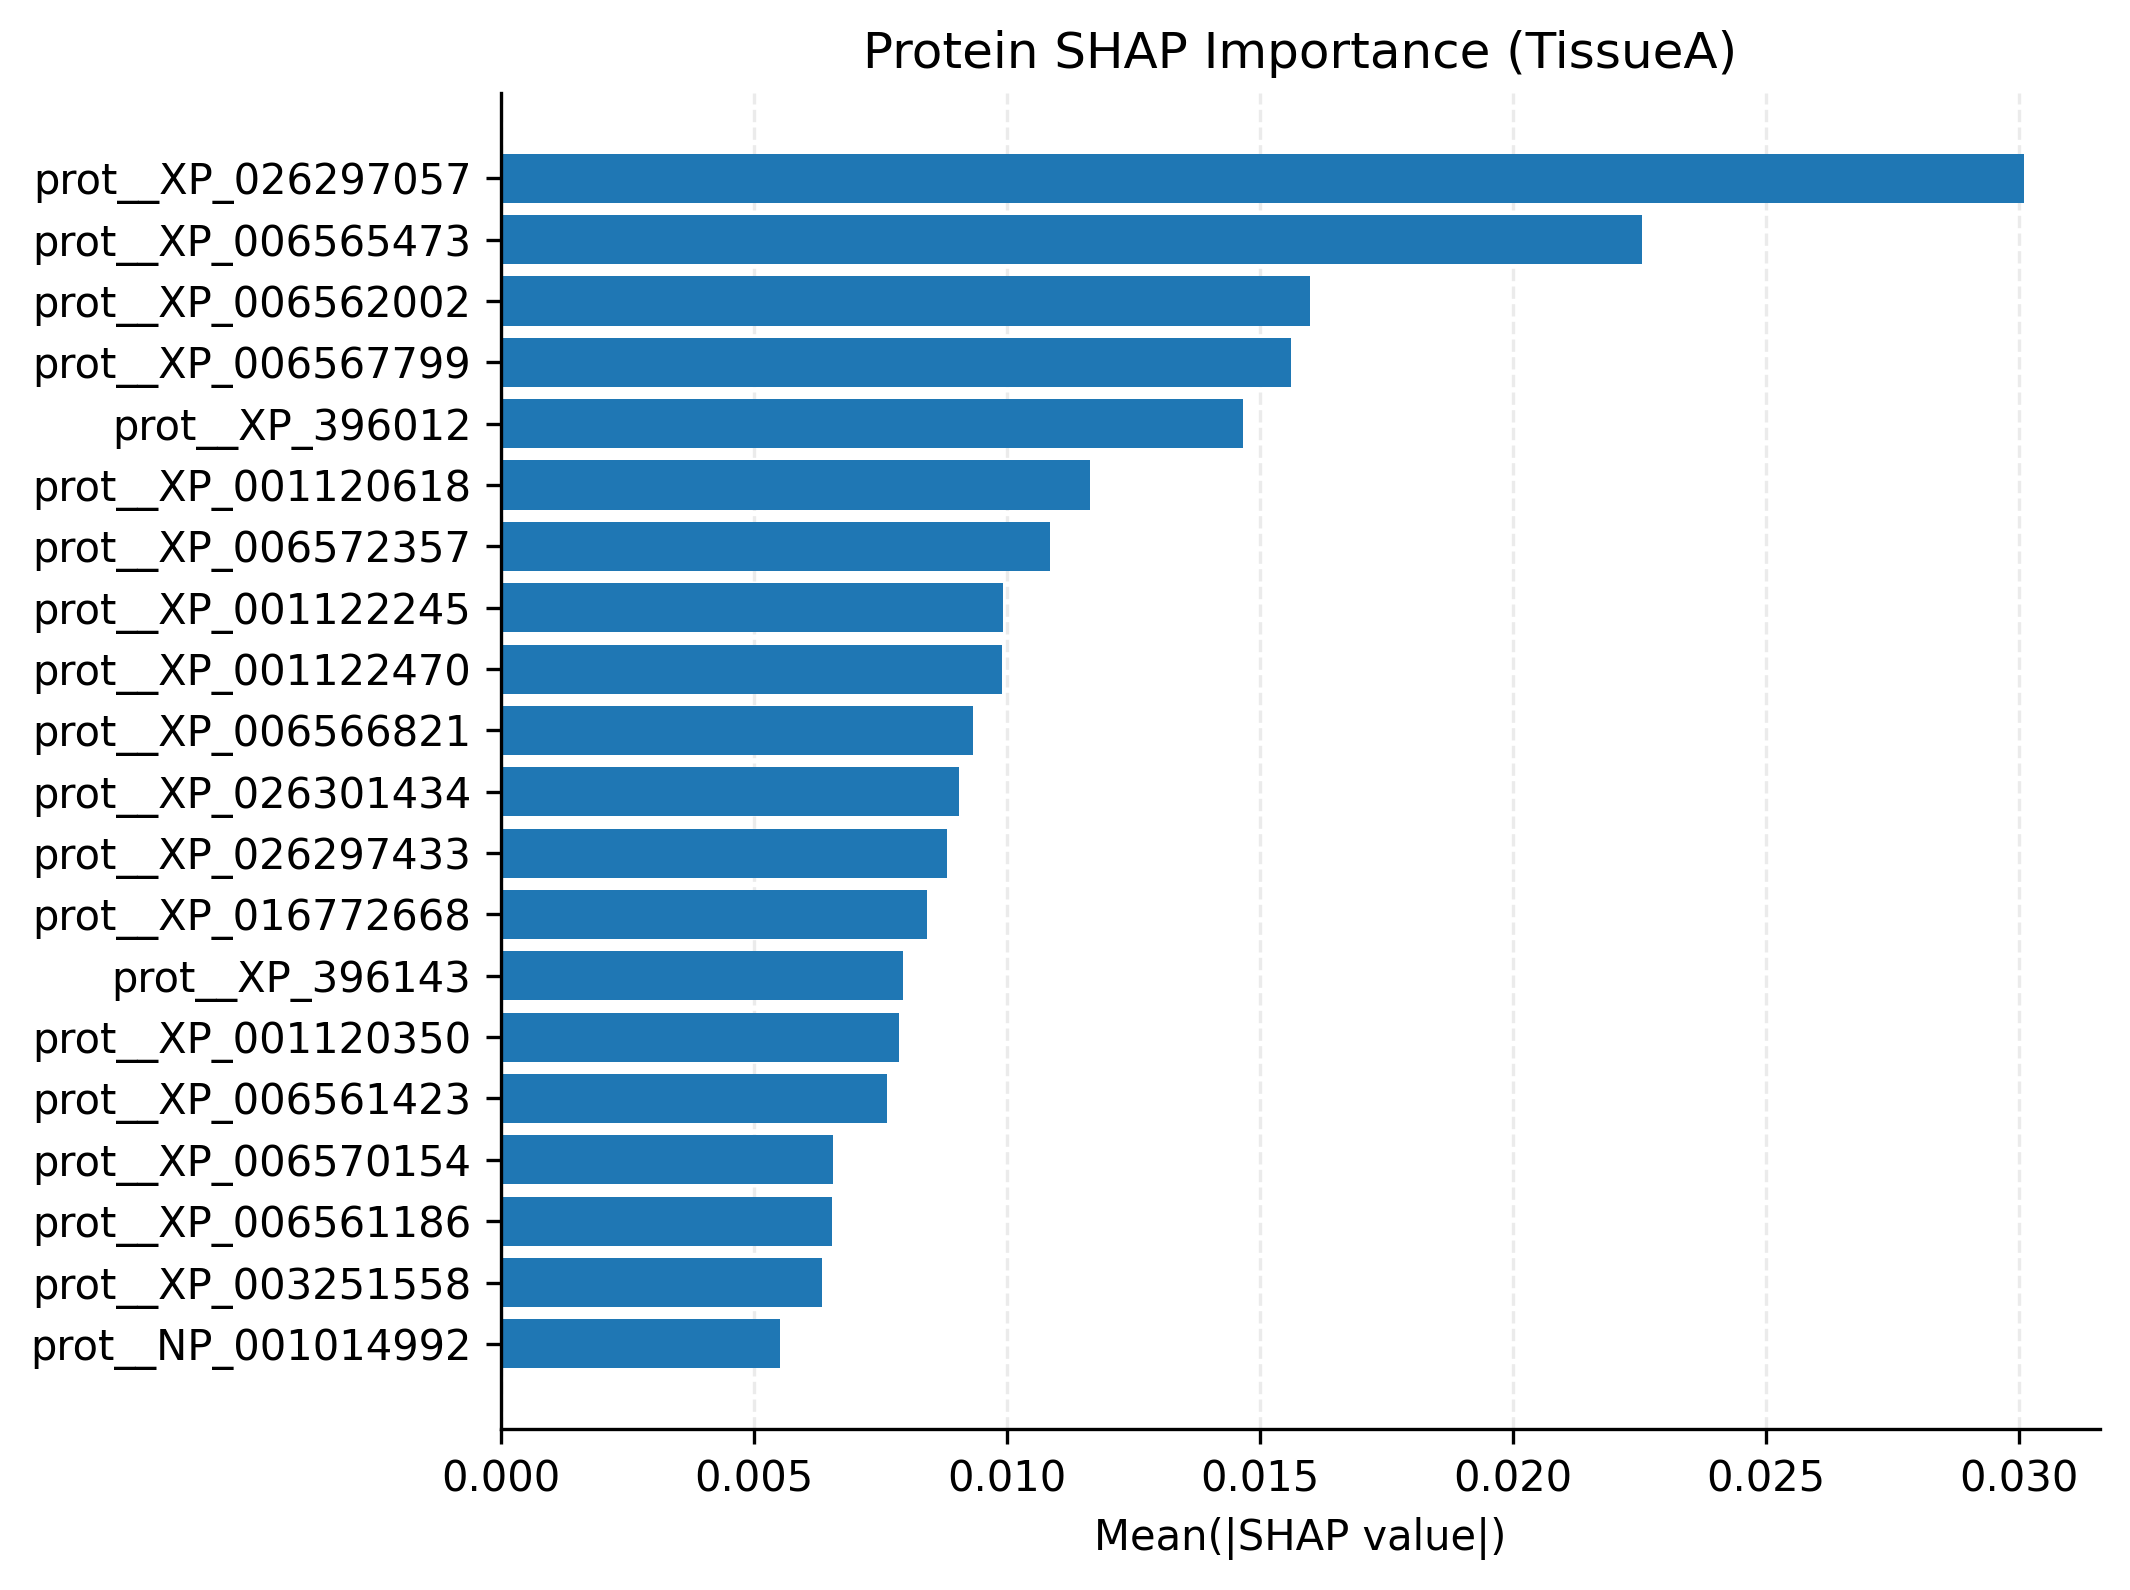

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_Protein_SHAP_bar_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_Protein_SHAP_bar_top20.png
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_Protein_SHAP_bar_top20_top20.csv

[TOP 20] Protein


,feature,mean_abs_shap
0,prot__XP_026297057,0.030101
1,prot__XP_006565473,0.022563
2,prot__XP_006562002,0.016004
3,prot__XP_006567799,0.015629
4,prot__XP_396012,0.014666
5,prot__XP_001120618,0.011638
6,prot__XP_006572357,0.010852
7,prot__XP_001122245,0.009922
8,prot__XP_001122470,0.009908
9,prot__XP_006566821,0.009331


In [23]:
# ============================================================
# Cell 1) Protein SHAP (paper-style bar plot)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from IPython.display import display

# -----------------------------
# 0) Save folder
# -----------------------------
TISSUE_TAG = globals().get("tissue_id", "TissueA")

if "FIG_DIR" in globals():
    FIG_TISSUE_DIR = Path(FIG_DIR).parent / "Figure_tissue"
else:
    FIG_TISSUE_DIR = Path("/content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue")

SHAP_DIR = FIG_TISSUE_DIR / "SHAP_paper"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print("[INFO] SHAP_DIR:", SHAP_DIR)

# -----------------------------
# 1) Helper functions
# -----------------------------
def _ensure_df(X):
    if isinstance(X, pd.DataFrame):
        return X.copy()
    X = np.asarray(X)
    return pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])

def _compute_shap_tensor_tree(model, X_df, max_eval=2000, max_bg=300, random_state=42):
    rng = np.random.RandomState(random_state)
    X_df = _ensure_df(X_df)

    # evaluation subset
    if len(X_df) > max_eval:
        idx = rng.choice(len(X_df), size=max_eval, replace=False)
        X_eval = X_df.iloc[idx].copy()
    else:
        X_eval = X_df.copy()

    # background subset
    if len(X_eval) > max_bg:
        bidx = rng.choice(len(X_eval), size=max_bg, replace=False)
        X_bg = X_eval.iloc[bidx].copy()
    else:
        X_bg = X_eval.copy()

    explainer = shap.TreeExplainer(
        model,
        data=X_bg,
        feature_perturbation="interventional"
    )
    shap_out = explainer.shap_values(X_eval)

    # Normalize shape to (K, n, d)
    if isinstance(shap_out, list):
        S = np.stack([np.asarray(s) for s in shap_out], axis=0)
    else:
        A = np.asarray(shap_out)
        if A.ndim == 3:
            # possible shapes: (n,d,K) or (K,n,d)
            if A.shape[0] == len(X_eval) and A.shape[1] == X_eval.shape[1]:
                S = np.transpose(A, (2, 0, 1))   # (n,d,K) -> (K,n,d)
            elif A.shape[1] == len(X_eval) and A.shape[2] == X_eval.shape[1]:
                S = A                             # already (K,n,d)
            else:
                S = np.transpose(A, (2, 0, 1))
        elif A.ndim == 2:
            S = A[None, :, :]                    # binary-like fallback
        else:
            raise ValueError(f"Unexpected SHAP shape: {A.shape}")

    return S, X_eval

def plot_shap_bar_paper(model, X_eval_df, title, out_stem, out_dir, top_n=20, max_eval=2000, max_bg=300, random_state=42):
    X_eval_df = _ensure_df(X_eval_df)

    S, X_used = _compute_shap_tensor_tree(
        model=model,
        X_df=X_eval_df,
        max_eval=max_eval,
        max_bg=max_bg,
        random_state=random_state,
    )

    # global importance = mean over classes and samples of |SHAP|
    mean_abs = np.mean(np.abs(S), axis=(0, 1))

    imp_df = pd.DataFrame({
        "feature": X_used.columns,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    top_df = imp_df.head(top_n).copy().iloc[::-1]

    fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=300)
    ax.barh(top_df["feature"], top_df["mean_abs_shap"])

    ax.set_xlabel("Mean(|SHAP value|)")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()

    out_pdf = Path(out_dir) / f"{out_stem}.pdf"
    out_png = Path(out_dir) / f"{out_stem}.png"
    out_csv = Path(out_dir) / f"{out_stem}_top{top_n}.csv"

    plt.savefig(out_pdf, bbox_inches="tight")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    top_df.iloc[::-1].to_csv(out_csv, index=False)

    plt.show()
    plt.close()

    print("[SAVED]", out_pdf)
    print("[SAVED]", out_png)
    print("[SAVED]", out_csv)

    return imp_df

# -----------------------------
# 2) Protein model + eval data
# -----------------------------
prot_model = next(m["best_rf"] for m in member_outputs if m["omic"] == "prot")

prot_selected_cols = load_selected_cols_from_csv(SAVE_DIR, mode="per_omic", omic="prot")
Xtr_std_prot, Xva_std_prot = fit_preprocess_train_val(
    preprocessing,
    data_dict_train["prot"],
    data_dict_valid["prot"]
)

prot_sel = [c for c in prot_selected_cols if c in Xtr_std_prot.columns]
if len(prot_sel) == 0:
    raise ValueError("[ERROR] Protein selected features are empty after intersection.")

X_prot_eval = Xva_std_prot[prot_sel].copy()

# -----------------------------
# 3) Plot
# -----------------------------
prot_imp_df = plot_shap_bar_paper(
    model=prot_model,
    X_eval_df=X_prot_eval,
    title=f"Protein SHAP Importance ({TISSUE_TAG})",
    out_stem=f"{TISSUE_TAG}_Protein_SHAP_bar_top20",
    out_dir=SHAP_DIR,
    top_n=20,
    max_eval=2000,
    max_bg=300,
    random_state=42,
)

print("\n[TOP 20] Protein")
display(prot_imp_df.head(20))

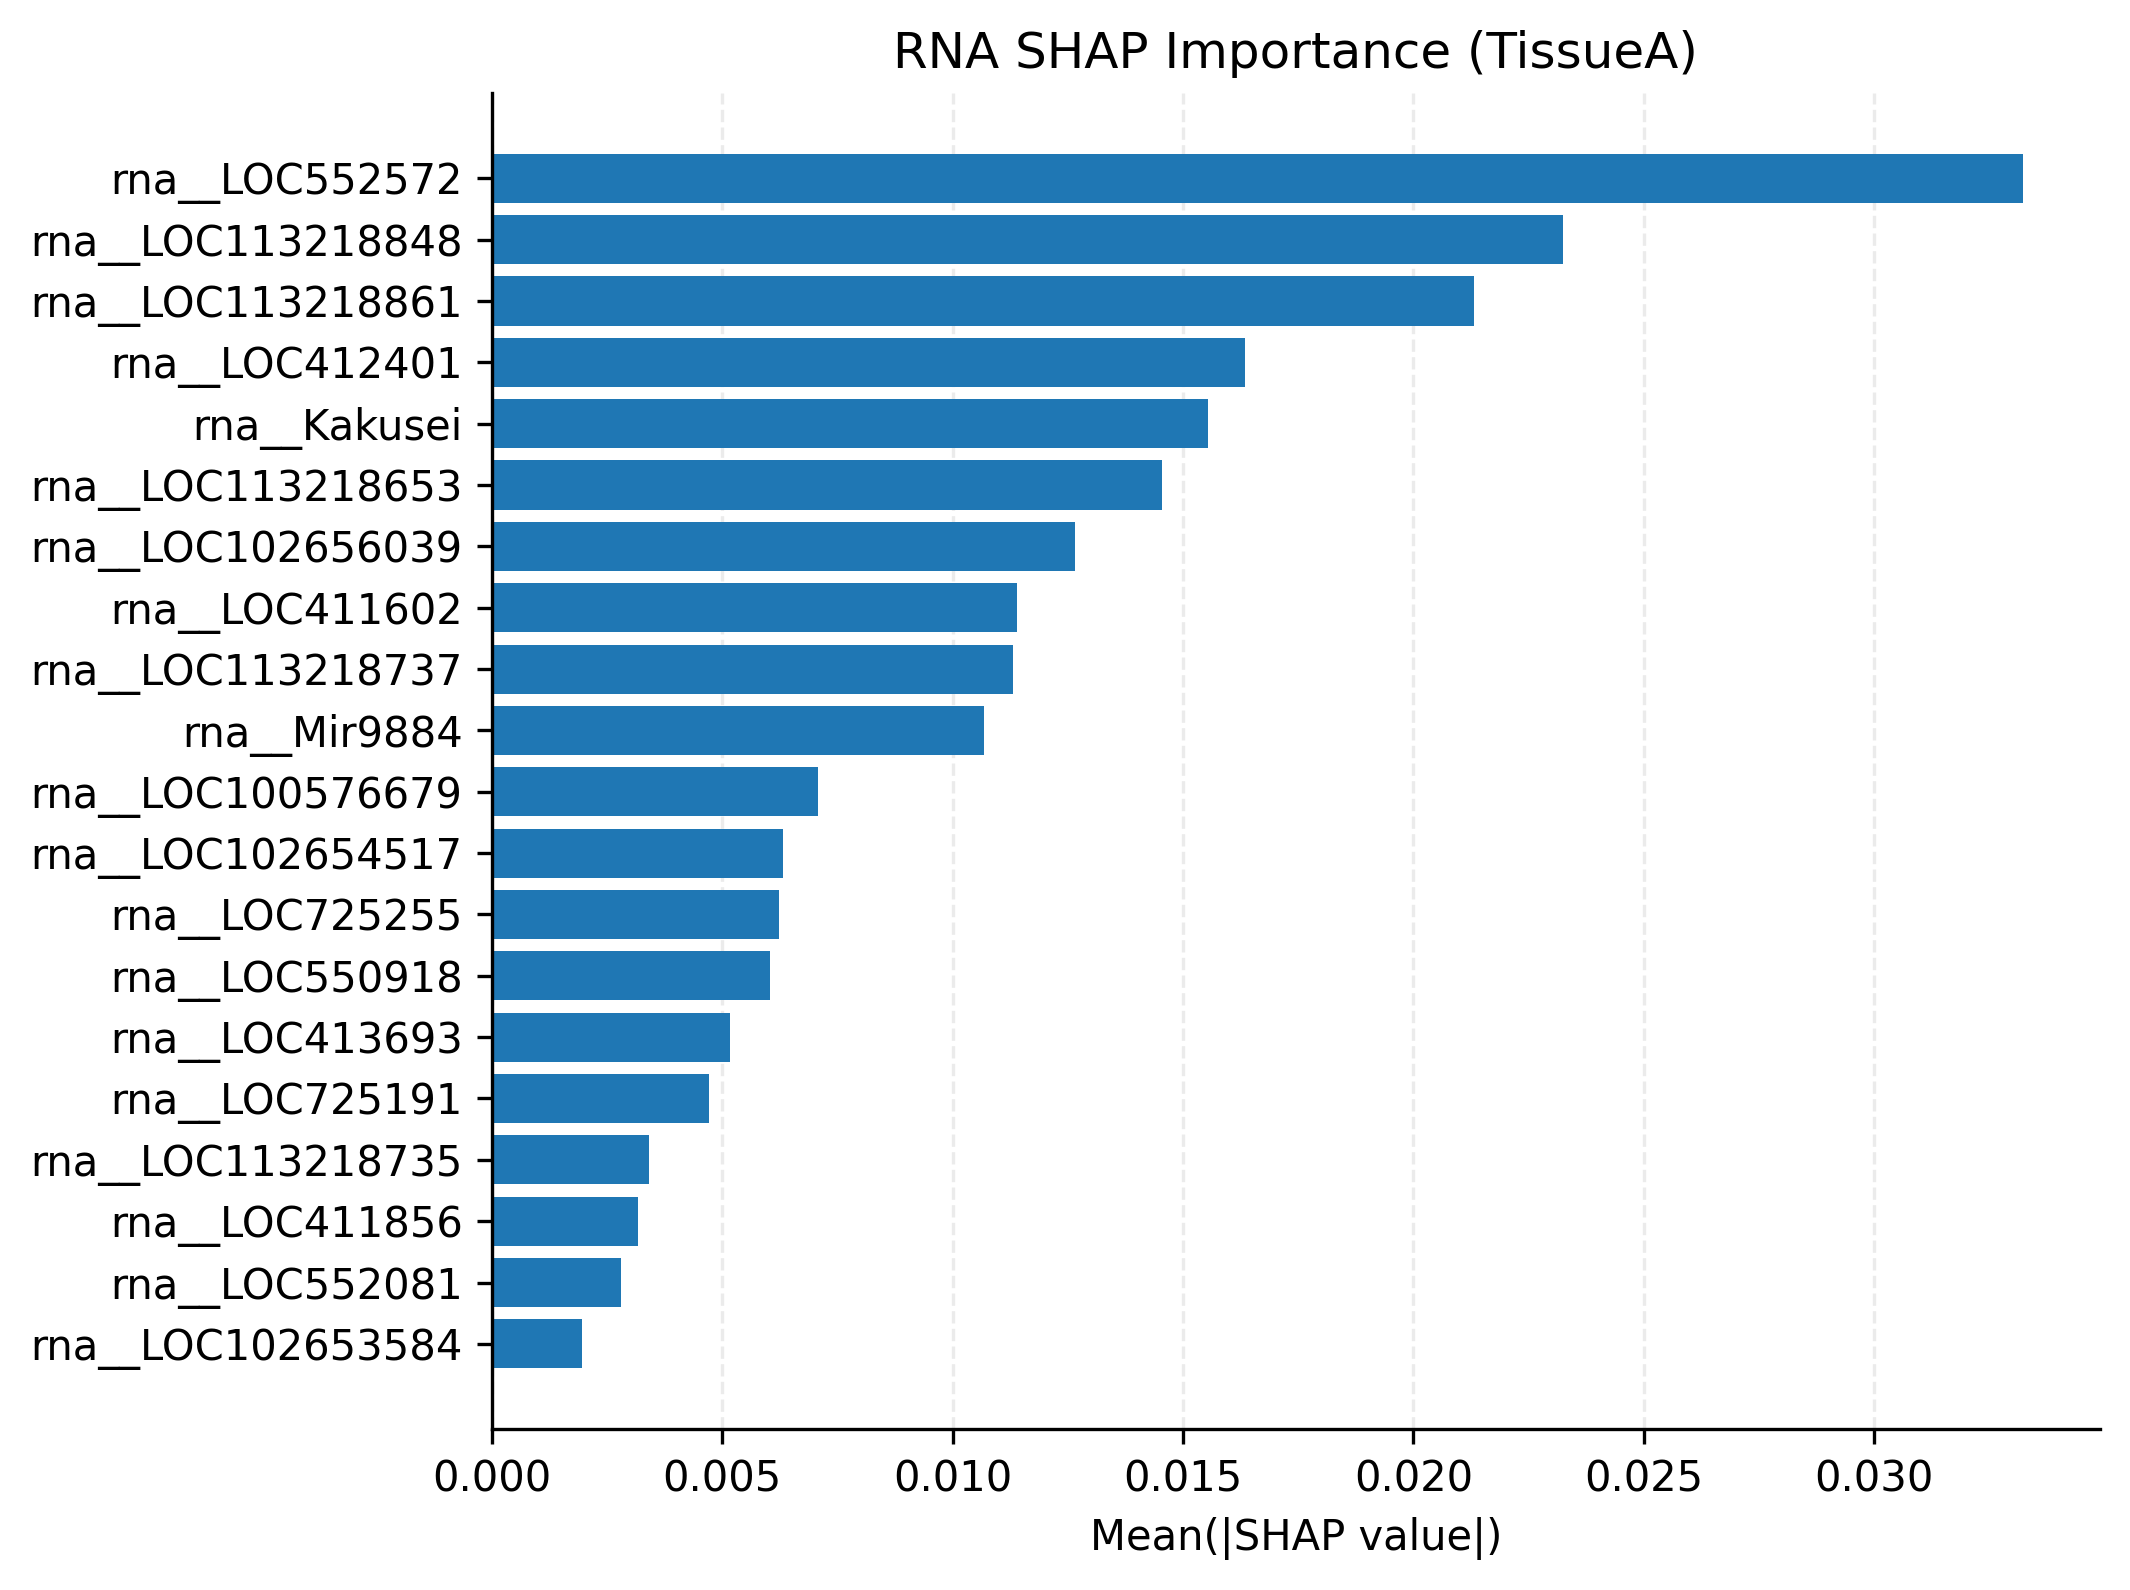

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_RNA_SHAP_bar_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_RNA_SHAP_bar_top20.png
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_RNA_SHAP_bar_top20_top20.csv

[TOP 20] RNA


,feature,mean_abs_shap
0,rna__LOC552572,0.033236
1,rna__LOC113218848,0.023249
2,rna__LOC113218861,0.021311
3,rna__LOC412401,0.016351
4,rna__Kakusei,0.015538
5,rna__LOC113218653,0.014542
6,rna__LOC102656039,0.012652
7,rna__LOC411602,0.011407
8,rna__LOC113218737,0.011317
9,rna__Mir9884,0.010689


In [24]:
# ============================================================
# Cell 2) RNA SHAP (paper-style bar plot)
# ============================================================

rna_model = next(m["best_rf"] for m in member_outputs if m["omic"] == "rna")

rna_selected_cols = load_selected_cols_from_csv(SAVE_DIR, mode="per_omic", omic="rna")
Xtr_std_rna, Xva_std_rna = fit_preprocess_train_val(
    preprocessing,
    data_dict_train["rna"],
    data_dict_valid["rna"]
)

rna_sel = [c for c in rna_selected_cols if c in Xtr_std_rna.columns]
if len(rna_sel) == 0:
    raise ValueError("[ERROR] RNA selected features are empty after intersection.")

X_rna_eval = Xva_std_rna[rna_sel].copy()

rna_imp_df = plot_shap_bar_paper(
    model=rna_model,
    X_eval_df=X_rna_eval,
    title=f"RNA SHAP Importance ({TISSUE_TAG})",
    out_stem=f"{TISSUE_TAG}_RNA_SHAP_bar_top20",
    out_dir=SHAP_DIR,
    top_n=20,
    max_eval=2000,
    max_bg=300,
    random_state=42,
)

print("\n[TOP 20] RNA")
display(rna_imp_df.head(20))

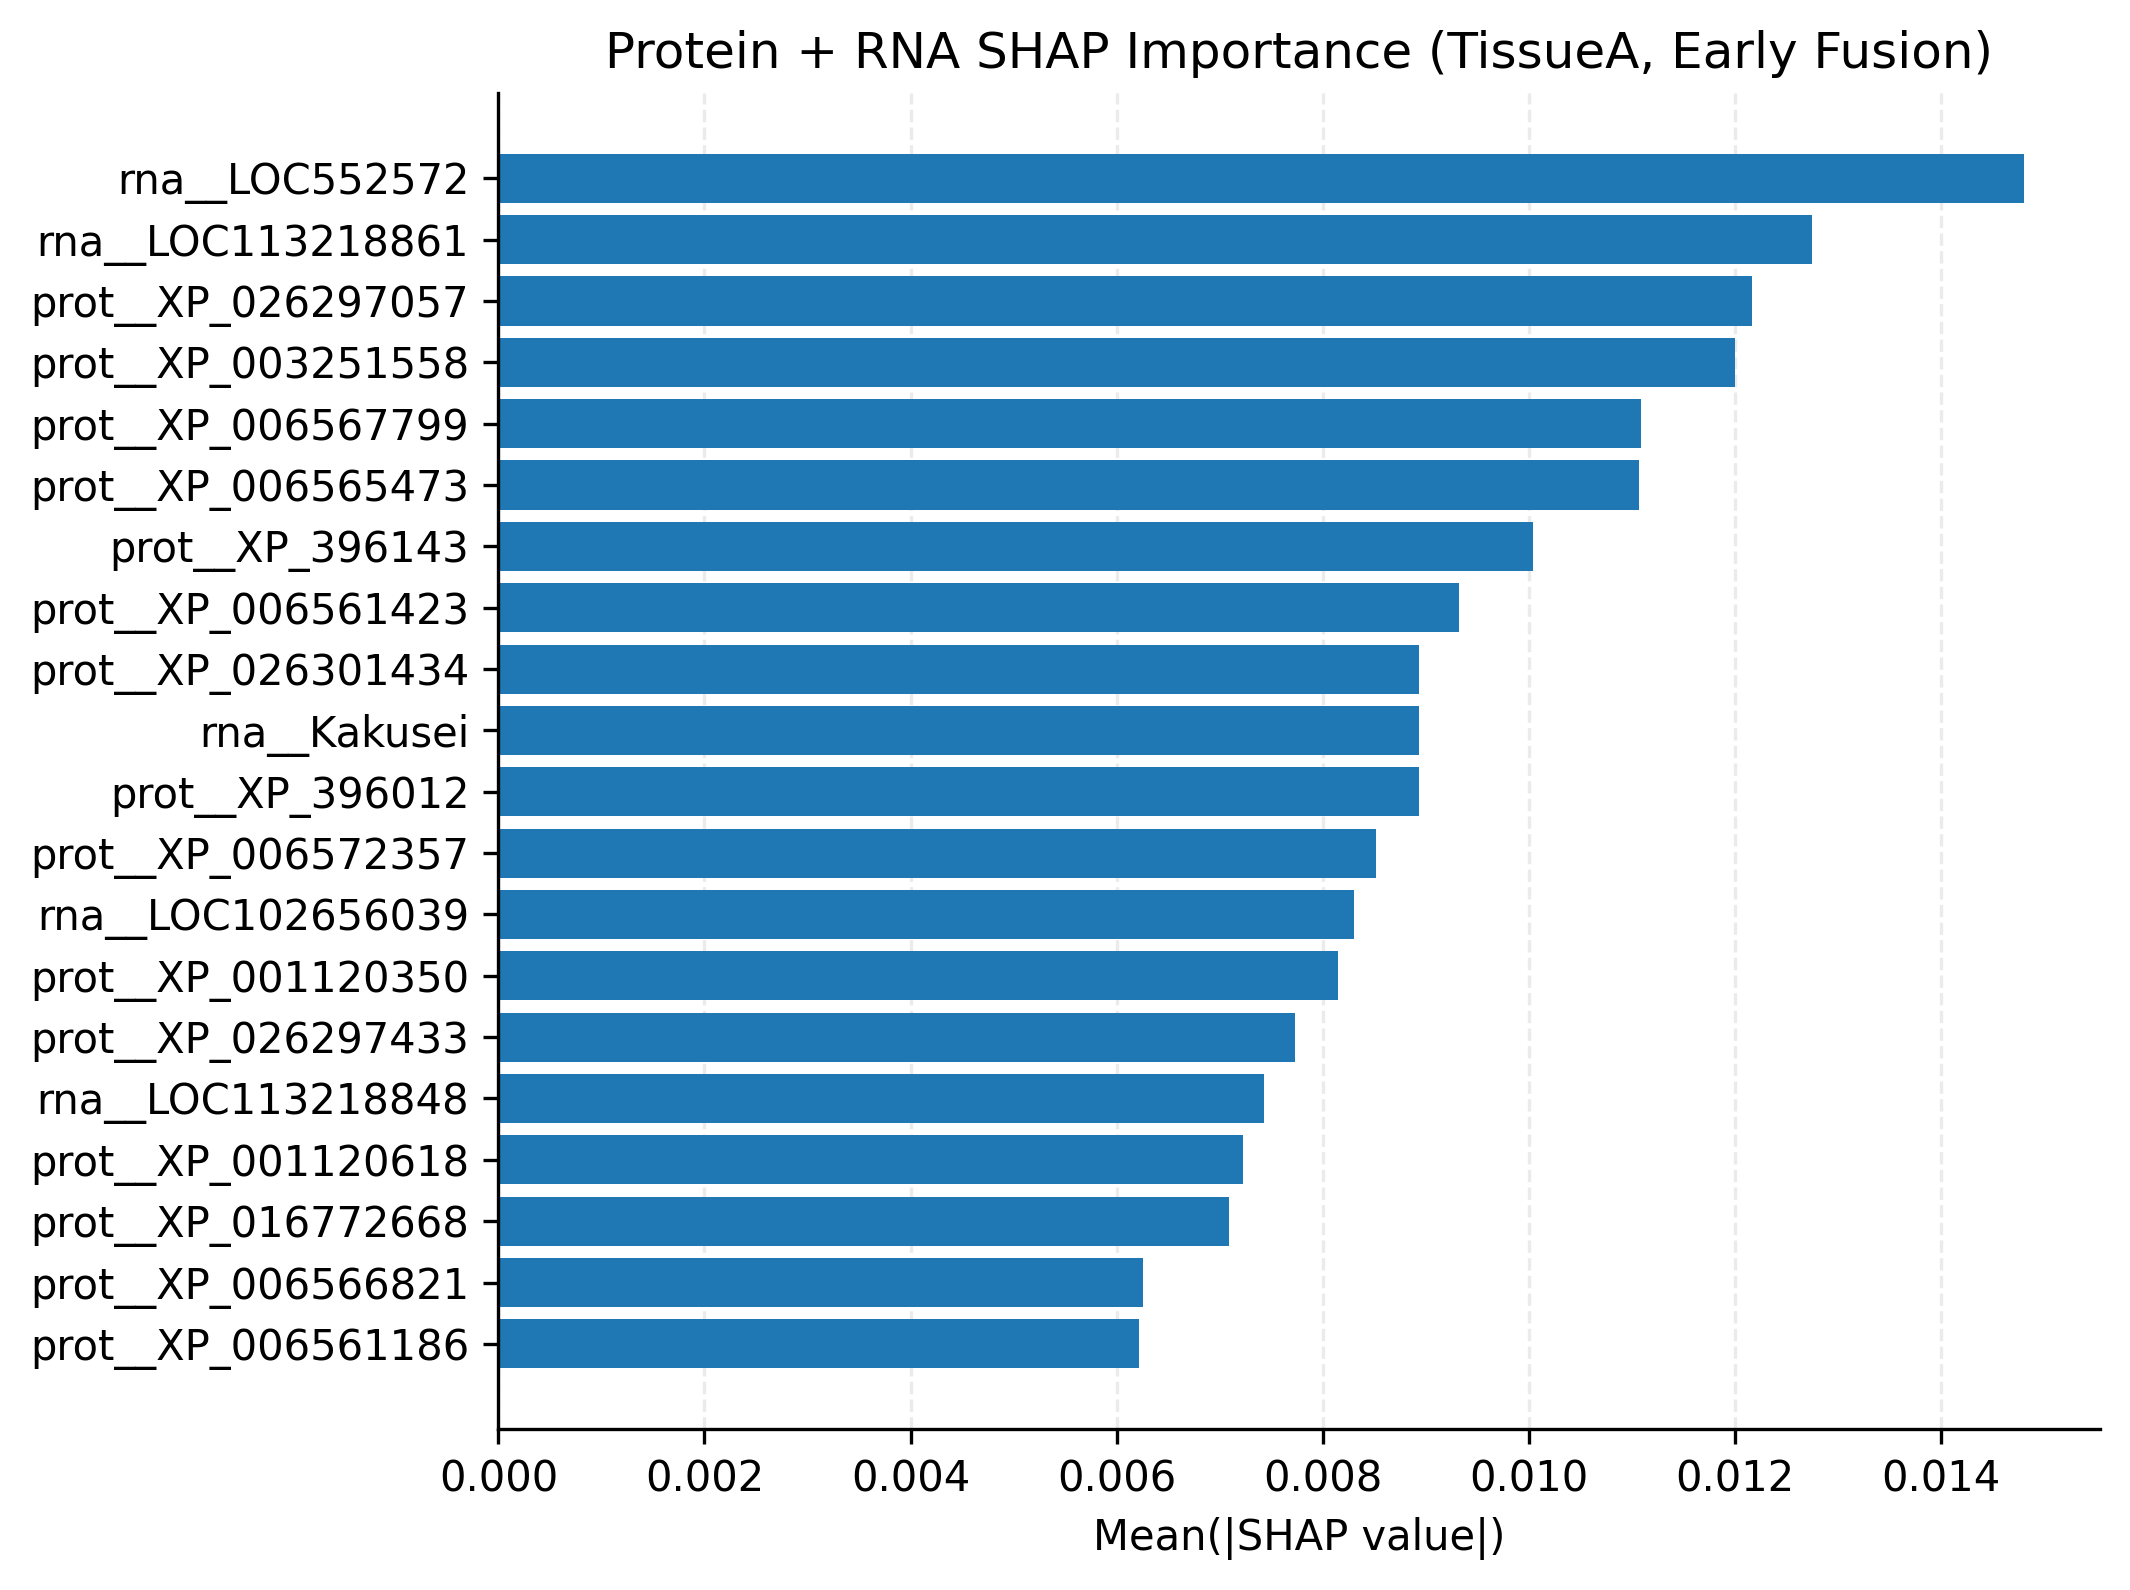

[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_ProteinRNA_EarlyFusion_SHAP_bar_top20.pdf
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_ProteinRNA_EarlyFusion_SHAP_bar_top20.png
[SAVED] /content/drive/MyDrive/Bee/stabl_RNA_Protein/Figure_tissue/SHAP_paper/TissueA_ProteinRNA_EarlyFusion_SHAP_bar_top20_top20.csv

[TOP 20] Protein + RNA (Early Fusion)


,feature,mean_abs_shap
0,rna__LOC552572,0.014805
1,rna__LOC113218861,0.012752
2,prot__XP_026297057,0.012166
3,prot__XP_003251558,0.011998
4,prot__XP_006567799,0.011091
5,prot__XP_006565473,0.011074
6,prot__XP_396143,0.010040
7,prot__XP_006561423,0.009319
8,prot__XP_026301434,0.008940
9,rna__Kakusei,0.008935


In [25]:
# ============================================================
# Cell 3) Protein + RNA SHAP (Early Fusion RF, paper-style)
# ============================================================

if "early_out" not in globals():
    raise ValueError("[ERROR] early_out is not defined. Run the early-fusion RF cell first.")

fusion_model = early_out["best_rf"]

fused_selected_cols = load_selected_cols_from_csv(SAVE_DIR, mode="fused")

Xtr_raw_fused = pd.concat(
    [data_dict_train["prot"], data_dict_train["rna"]],
    axis=1
)
Xva_raw_fused = pd.concat(
    [data_dict_valid["prot"], data_dict_valid["rna"]],
    axis=1
)

Xtr_std_fused, Xva_std_fused = fit_preprocess_train_val(
    preprocessing,
    Xtr_raw_fused,
    Xva_raw_fused
)

fused_sel = [c for c in fused_selected_cols if c in Xtr_std_fused.columns]
if len(fused_sel) == 0:
    raise ValueError("[ERROR] Fused selected features are empty after intersection.")

X_fused_eval = Xva_std_fused[fused_sel].copy()

fusion_imp_df = plot_shap_bar_paper(
    model=fusion_model,
    X_eval_df=X_fused_eval,
    title=f"Protein + RNA SHAP Importance ({TISSUE_TAG}, Early Fusion)",
    out_stem=f"{TISSUE_TAG}_ProteinRNA_EarlyFusion_SHAP_bar_top20",
    out_dir=SHAP_DIR,
    top_n=20,
    max_eval=2000,
    max_bg=300,
    random_state=42,
)

print("\n[TOP 20] Protein + RNA (Early Fusion)")
display(fusion_imp_df.head(20))